# Chapter 36: Elective Backlogs as a Stock

*Systems Thinking with AI* by Jason Karpeles

A waiting list is a level, and the chapter fits one to a public record without forecasting it.

**Goal.** Four small demonstrations on the England waiting list record that the chapter's pack reads. Check the stock arithmetic, see a fit pass and a holdout fail, rank what moves the long-wait stock, and read a recovery date that can honestly be None. Fitted values are inferred from the committed record. Varied values are constructed and are labelled so.

**Demonstrations**

1. A gap held open is the growth
2. A fit that passes and a holdout that fails
3. Which parameter decides the long-wait stock
4. A recovery date, or the honest None

The chapter's own model code is written out in full below, so the notebook runs with NumPy and Matplotlib alone. The interactive version of this chapter is at [https://karpeles.com/companions/systems-thinking-with-ai/36-elective-backlog/reader.html](https://karpeles.com/companions/systems-thinking-with-ai/36-elective-backlog/reader.html).

The observed series is the committed public record used by the chapter (NHS England referral-to-treatment national monthly series). Fitted values are inferred from that record, and nothing here is a forecast.

## Setup

Imports, plus two small helpers: `%%module` runs a cell as a named module so the chapter files can import one another by their package names, and `show` draws a demonstration's figure and lists its values.

In [1]:
import os, sys, tempfile, types
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from IPython.core.magic import register_cell_magic
from IPython.display import Markdown, display

%matplotlib inline

WORKDIR = tempfile.mkdtemp(prefix="systems-thinking-")


@register_cell_magic
def module(line, cell):
    """Run a cell as a named module so the chapter code can import it by name."""
    name = line.strip()
    parts = name.split(".")
    for i in range(1, len(parts)):
        parent = ".".join(parts[:i])
        if parent not in sys.modules:
            pkg = types.ModuleType(parent)
            pkg.__path__ = []
            sys.modules[parent] = pkg
            if i > 1:
                setattr(sys.modules[".".join(parts[:i - 1])], parts[i - 1], pkg)
    mod = types.ModuleType(name)
    mod.__file__ = os.path.join(WORKDIR, *parts) + ".py"
    mod.__package__ = ".".join(parts[:-1])
    sys.modules[name] = mod
    if len(parts) > 1:
        setattr(sys.modules[".".join(parts[:-1])], parts[-1], mod)
    exec(compile(cell, name, "exec"), mod.__dict__)


def show(result):
    """Draw the figure, then list the calculated values and the reading."""
    fig, metrics, interpretation = result[:3]
    plt.show()
    display(Markdown("\n".join(f"- **{k}:** {v}" for k, v in metrics.items())))
    display(Markdown(interpretation))


def sweep(function, controls):
    """Recompute every setting offered in the interactive reader and list the values."""
    import itertools
    keys = [k for k, _ in controls]
    rows = []
    for combo in itertools.product(*[v for _, v in controls]):
        fig, metrics, _ = function(**dict(zip(keys, combo)))[:3]
        plt.close(fig)
        setting = ", ".join(f"{k} = {v}" for k, v in zip(keys, combo))
        rows.append(f"- **{setting}**: " + "; ".join(f"{k} {v}" for k, v in metrics.items()))
    display(Markdown("\n".join(rows)))


## The public record

The chapter reads its observed series from these files. They are written into a working folder so the model code reads them exactly as the book does.

In [2]:
RECORD_FILES = {}
RECORD_FILES['data/nhs_rtt/rtt_national_monthly.csv'] = '''\
period,total_incomplete,within_18_weeks,over_18_weeks,over_52_weeks,over_65_weeks,over_78_weeks,over_104_weeks,median_wait_weeks,new_periods,completed_pathways,unreported_removals,total_removals
2007-08,4186974,2395656,1791318,578682,,,,14.29,,1119858,,
2007-09,3997551,2364349,1633202,401725,,,,13.35,,1124467,,
2007-10,3939821,2337604,1602217,387161,,,,13.15,,1229902,,
2007-11,3921962,2269968,1651994,415215,,,,13.33,,1234148,,
2007-12,3853836,2173205,1680631,434180,,,,14.28,,987029,,
2008-01,3510437,2151167,1359270,306034,,,,12.28,,1209304,,
2008-02,3116073,2024628,1091445,253955,,,,10.52,,1131380,,
2008-03,3056710,2017806,1038904,240689,,,,9.83,,1007994,,
2008-04,2940270,2041274,898996,225860,,,,9.02,,1148689,,
2008-05,2871949,2103566,768383,187394,,,,8.09,,1035246,,
2008-06,2743336,2126177,617159,149029,,,,7.41,,1101393,,
2008-07,2641644,2142703,498941,118801,,,,6.93,,1160408,,
2008-08,2675732,2155168,520564,140727,,,,7.27,,978420,,
2008-09,2633591,2162608,470983,144213,,,,6.80,,1142375,,
2008-10,2474846,2104538,370308,83601,,,,6.23,,1203339,,
2008-11,2432758,2082990,349768,93080,,,,6.26,,1103067,,
2008-12,2345732,1998655,347077,79418,,,,6.94,,1041859,,
2009-01,2303305,1969144,334161,82232,,,,6.73,,1129849,,
2009-02,2310322,2013965,296357,50678,,,,5.72,,1043523,,
2009-03,2360453,2067346,293107,47013,,,,5.56,,1222884,,
2009-04,2417946,2167437,250509,31800,,,,5.72,,1135122,,
2009-05,2444901,2194642,250259,31065,,,,5.74,,1094532,,
2009-06,2482691,2246375,236316,31628,,,,5.61,,1280318,,
2009-07,2481566,2241908,239658,32563,,,,5.76,,1276210,,
2009-08,2459949,2218857,241092,31608,,,,6.05,,1086440,,
2009-09,2428692,2191974,236718,31756,,,,5.93,,1257165,,
2009-10,2376360,2147615,228745,23388,,,,5.69,,1237604,,
2009-11,2337575,2114966,222609,21619,,,,5.71,,1227055,,
2009-12,2365316,2128078,237238,20792,,,,6.49,,1089904,,
2010-01,2315060,2075443,239617,20737,,,,6.55,,1098713,,
2010-02,2337098,2109462,227636,18681,,,,5.31,,1146611,,
2010-03,2420525,2205542,214983,18494,,,,5.24,,1330771,,
2010-04,2508495,2290852,217643,21098,,,,5.63,,1130801,,
2010-05,2573895,2364484,209411,18458,,,,5.53,,1150595,,
2010-06,2569098,2347510,221588,18221,,,,5.68,,1283641,,
2010-07,2656614,2413409,243205,19585,,,,5.80,,1253923,,
2010-08,2654900,2391511,263389,20855,,,,6.23,,1163055,,
2010-09,2590970,2341244,249726,13442,,,,6.02,,1261045,,
2010-10,2571819,2320939,250880,14254,,,,5.86,,1187485,,
2010-11,2526792,2274528,252264,13568,,,,5.86,,1269229,,
2010-12,2411293,2135754,275539,14671,,,,6.91,,1002574,,
2011-01,2369585,2093487,276098,14222,,,,6.52,,1135975,,
2011-02,2441735,2164846,276889,14880,,,,5.48,,1111556,,
2011-03,2455424,2196360,259064,14355,,,,5.45,,1290590,,
2011-04,2473680,2237539,236141,13434,,,,6.01,,1010131,,
2011-05,2544162,2318419,225743,12536,,,,6.13,,1174473,,
2011-06,2550720,2324293,226427,13257,,,,5.65,,1259294,,
2011-07,2611906,2364495,247411,19937,,,,5.76,,1154455,,
2011-08,2614998,2369340,245658,19938,,,,6.17,,1176824,,
2011-09,2597388,2353826,243562,20097,,,,6.04,,1221342,,
2011-10,2567505,2333475,234030,11132,,,,5.73,,1189446,,
2011-11,2500701,2282411,218290,7324,,,,5.72,,1268595,,
2011-12,2385147,2180122,205025,6071,,,,6.31,,1035844,,
2012-01,2358616,2174872,183744,5898,,,,5.93,,1183200,,
2012-02,2381172,2205482,175690,5653,,,,5.18,,1145024,,
2012-03,2413969,2252479,161490,5149,,,,5.21,,1215371,,
2012-04,2480664,2333158,147506,4213,,,,5.48,,1054435,,
2012-05,2556698,2414369,142329,3308,,,,5.29,,1270851,,
2012-06,2635475,2481026,154449,3478,,,,5.71,,1065541,,
2012-07,2681884,2521975,159909,2959,,,,5.47,,1237268,,
2012-08,2636514,2492105,144409,2054,,,,5.85,,1172537,,
2012-09,2641049,2492388,148661,1570,,,,5.80,,1145725,,
2012-10,2636826,2498882,137944,1281,,,,5.31,,1338816,,
2012-11,2590737,2455642,135095,1147,,,,5.40,,1278415,,
2012-12,2565126,2423808,141318,1085,,,,6.08,,1014260,,
2013-01,2537530,2393789,143741,842,,,,6.04,,1271371,,
2013-02,2571993,2425992,146001,663,,,,5.12,,1155696,,
2013-03,2661165,2508128,153037,473,,,,5.50,,1151687,,
2013-04,2748808,2596934,151874,391,,,,5.56,,1134795,,
2013-05,2847373,2699788,147585,434,,,,5.61,,1148205,,
2013-06,2879204,2724755,154449,295,,,,5.68,,1111684,,
2013-07,2906489,2745065,161424,368,,,,5.63,,1241084,,
2013-08,2936981,2767545,169436,350,,,,6.16,,1064689,,
2013-09,2903316,2734352,168964,387,,,,5.95,,1158482,,
2013-10,2912243,2742336,169907,257,,,,5.59,,1268321,,
2013-11,2879129,2705480,173649,214,,,,5.71,,1201937,,
2013-12,2880156,2695700,184456,316,,,,6.28,,1034636,,
2014-01,2905331,2715719,189612,430,,,,6.23,,1248787,,
2014-02,2911205,2719650,191555,539,,,,5.41,,1125899,,
2014-03,2911442,2729396,182046,488,,,,5.46,,1192667,,
2014-04,3020111,2831337,188774,516,,,,5.87,,1146937,,
2014-05,3096929,2903097,193832,572,,,,6.22,,1157776,,
2014-06,3136096,2939344,196752,594,,,,5.78,,1234549,,
2014-07,3070250,2864937,205313,532,,,,5.86,,1267528,,
2014-08,3090525,2878288,212237,490,,,,6.44,,1062016,,
2014-09,2991237,2795366,195871,362,,,,6.20,,1229394,,
2014-10,3005906,2801516,204390,381,,,,5.81,,1263678,,
2014-11,2990258,2790268,199990,362,,,,5.82,,1190553,,
2014-12,2928414,2718870,209544,399,,,,6.55,,1100963,,
2015-01,2924045,2706862,217183,440,,,,6.65,,1196323,,
2015-02,2928213,2725305,202908,442,,,,5.57,,1149978,,
2015-03,3006877,2800845,206032,475,,,,5.56,,1266376,,
2015-04,3022512,2821088,201424,413,,,,5.92,,1139275,,
2015-05,3172627,2965989,206638,634,,,,6.01,,1115489,,
2015-06,3197125,2980377,216748,751,,,,6.02,,1298913,,
2015-07,3260044,3027537,232507,786,,,,5.97,,1286308,,
2015-08,3327055,3080794,246261,739,,,,6.47,,1107934,,
2015-09,3305892,3058504,247388,756,,,,6.52,,1273714,,
2015-10,3313910,3059956,253954,868,,,,6.16,1485369,1270076,207275,1477351
2015-11,3306510,3055104,251406,835,,,,6.06,1450031,1277073,180358,1457431
2015-12,3295912,3026929,268983,758,,,,6.74,1351414,1146366,215646,1362012
2016-01,3291100,3027654,263446,728,,,,6.85,1434066,1213763,225115,1438878
2016-02,3345921,3082332,263589,692,,,,5.85,1505461,1241480,209160,1450640
2016-03,3504595,3205842,298753,871,,,,6.35,1572127,1252822,160631,1413453
2016-04,3603606,3300705,302901,886,,,,6.57,1583739,1242025,242703,1484728
2016-05,3659207,3359901,299306,1009,,,,6.42,1550496,1272141,222754,1494895
2016-06,3627894,3320719,307175,942,,,,6.46,1601725,1335689,297349,1633038
2016-07,3664685,3344181,320504,1077,,,,6.59,1532038,1238259,256988,1495247
2016-08,3691604,3355134,336470,1062,,,,6.96,1532416,1261084,244413,1505497
2016-09,3702580,3354034,348546,1185,,,,6.90,1588655,1324546,253133,1577679
2016-10,3754806,3394756,360050,1428,,,,6.53,1573928,1325951,195751,1521702
2016-11,3721165,3367511,353654,1234,,,,6.47,1657024,1435570,255095,1690665
2016-12,3654268,3278063,376205,1227,,,,7.17,1398622,1172772,292747,1465519
2017-01,3615335,3252604,362731,1345,,,,7.19,1588726,1349270,278389,1627659
2017-02,3663999,3296902,367097,1583,,,,6.20,1532687,1278014,206009,1484023
2017-03,3734833,3372306,362527,1528,,,,6.18,1787232,1456042,260356,1716398
2017-04,3782457,3399969,382488,1568,,,,6.80,1436983,1162826,226533,1389359
2017-05,3811039,3445317,365722,1651,,,,7.10,1666097,1376303,261212,1637515
2017-06,3832987,3459659,373328,1542,,,,6.64,1711834,1384342,305544,1689886
2017-07,3851074,3460415,390659,1642,,,,6.58,1625701,1331972,275642,1607614
2017-08,3886219,3474471,411748,1734,,,,7.07,1612863,1322800,254918,1577718
2017-09,3833300,3415529,417771,1778,,,,7.19,1568564,1305474,316009,1621483
2017-10,3800047,3393766,406281,1519,,,,6.69,1669601,1400048,302806,1702854
2017-11,3722600,3330962,391638,1449,,,,6.61,1644925,1426607,295765,1722372
2017-12,3767326,3321954,445372,1748,,,,7.44,1336987,1125395,166866,1292261
2018-01,3730473,3289620,440853,1869,,,,7.56,1657878,1392937,301794,1694731
2018-02,3763533,3309184,454349,2235,,,,6.59,1522794,1241898,247836,1489734
2018-03,3852414,3361133,491281,2756,,,,6.93,1633324,1279412,265031,1544443
2018-04,4019507,3519434,500073,2880,,,,6.89,1640427,1289720,183614,1473334
2018-05,4089937,3604707,485230,3100,,,,6.88,1746208,1399319,276459,1675778
2018-06,4122380,3620601,501779,3516,,,,7.04,1675427,1363719,279265,1642984
2018-07,4135261,3630924,504337,3464,,,,7.05,1714390,1395273,306236,1701509
2018-08,4163332,3632958,530374,3405,,,,7.54,1634177,1306429,299677,1606106
2018-09,4134701,3584289,550412,3157,,,,7.63,1553736,1292982,289385,1582367
2018-10,4186342,3646101,540241,2815,,,,7.00,1841759,1509418,280700,1790118
2018-11,4154046,3626281,527765,2431,,,,6.91,1757848,1484729,305415,1790144
2018-12,4151589,3595561,556028,2237,,,,7.59,1431137,1189325,244269,1433594
2019-01,4172662,3619513,553149,2169,,,,7.76,1794128,1500753,272302,1773055
2019-02,4144110,3604256,539854,1962,,,,6.69,1638322,1317524,349350,1666874
2019-03,4233414,3670437,562977,1154,,,,6.88,1741493,1401057,251132,1652189
2019-04,4297571,3718168,579403,1047,,,,7.25,1656081,1326224,265700,1591924
2019-05,4385693,3809456,576237,1032,,,,7.73,1755805,1398839,268844,1667683
2019-06,4395246,3794158,601088,1089,,,,7.49,1641179,1353704,277922,1631626
2019-07,4372568,3752114,620454,1032,,,,7.35,1801797,1493426,331049,1824475
2019-08,4407964,3745921,662043,1236,,,,8.02,1577132,1281412,260324,1541736
2019-09,4416883,3744771,672112,1305,,,,7.99,1637851,1369040,259892,1628932
2019-10,4444856,3763231,681625,1321,,,,7.56,1812825,1514306,270546,1784852
2019-11,4413478,3723382,690096,1398,,,,7.66,1656910,1423581,264707,1688288
2019-12,4414911,3693390,721521,1467,,,,8.33,1459872,1219828,238611,1458439
2020-01,4415694,3685428,730266,1643,,,,8.45,1738294,1464782,272729,1737511
2020-02,4423348,3678351,744997,1613,,,,7.52,1600454,1341713,251087,1592800
2020-03,4235970,3375661,860309,3097,,,,8.94,1220636,1186426,221588,1408014
2020-04,3947061,2812999,1134062,11179,,,,12.23,491101,569514,210496,780010
2020-05,3846003,2392303,1453700,26717,,,,15.30,626540,562067,165531,727598
2020-06,3860077,2005831,1854246,50539,,,,17.59,939450,757010,168366,925376
2020-07,4046707,1895264,2151443,83203,,,,19.55,1178528,870091,121807,991898
2020-08,4220115,2260431,1959684,111026,,,,14.76,1114414,823750,117256,941006
2020-09,4354884,2638278,1716606,139545,,,,12.04,1332834,1057911,140154,1198065
2020-10,4448857,2911270,1537587,167067,,,,11.12,1393861,1138710,161178,1299888
2020-11,4460712,3040809,1419903,192169,,,,10.41,1348049,1164352,171842,1336194
2020-12,4521333,3067658,1453675,224205,,,,11.22,1260501,1039182,160698,1199880
2021-01,4592675,3038370,1554305,304044,,,,12.12,1185074,961596,152136,1113732
2021-02,4698348,3030448,1667900,387885,,,,12.59,1253853,971868,176312,1148180
2021-03,4950297,3186952,1763345,436127,,,,11.58,1614201,1233677,128575,1362252
2021-04,5123717,3311746,1811971,385379,196225,64846,2608,11.01,1497830,1159024,165386,1324410
2021-05,5305425,3576159,1729266,336779,232172,79055,3927,10.82,1516276,1198706,135862,1334568
2021-06,5453486,3749231,1704255,304823,233051,85959,5727,10.45,1674642,1338890,187691,1526581
2021-07,5607574,3828136,1779438,293102,199472,102304,7980,10.91,1605526,1262425,189013,1451438
2021-08,5715698,3865241,1850457,292138,176195,121711,9754,11.48,1469370,1139319,221927,1361246
2021-09,5834995,3879621,1955374,301274,163361,123969,12645,11.86,1626494,1293937,213260,1507197
2021-10,5977537,3923337,2054200,312852,158774,106258,16245,12.00,1588347,1283153,162652,1445805
2021-11,6001676,3933682,2067994,307214,148492,87437,18596,11.50,1683913,1420502,239272,1659774
2021-12,6071293,3876780,2194513,310943,155902,80121,20080,12.49,1428240,1169927,188696,1358623
2022-01,6127993,3826817,2301176,317491,163160,77566,24424,13.13,1518507,1250245,211562,1461807
2022-02,6211131,3862282,2348849,306479,156787,69275,22637,13.19,1552698,1267210,202350,1469560
2022-03,6365772,3956489,2409283,310067,144772,63397,16947,12.22,1786268,1439589,192038,1631627
2022-04,6483706,3998468,2485238,323261,141413,63688,12757,12.57,1495453,1173967,203552,1377519
2022-05,6638075,4215948,2422127,333119,136873,59901,8057,12.71,1740851,1388600,197882,1586482
2022-06,6760060,4207211,2552849,357577,142012,54106,3875,13.25,1604839,1301305,181549,1482854
2022-07,6840558,4174730,2665828,377886,148913,51885,2890,13.25,1602408,1278550,243360,1521910
2022-08,7005848,4258985,2746863,387538,156985,50959,2651,13.78,1649719,1334903,149526,1484429
2022-09,7075007,4204505,2870502,401895,165967,50612,2250,13.97,1631921,1363086,199676,1562762
2022-10,6955458,4183750,2771708,384015,157216,46210,1821,13.87,1660239,1379001,400787,1779788
2022-11,6929224,4162017,2767207,379540,147131,45038,1335,13.62,1742711,1517315,251630,1768945
2022-12,7008252,4066601,2941651,381985,154719,51124,1137,14.37,1402495,1201686,121781,1323467
2023-01,7213120,4207644,3005476,379145,144969,45610,1108,14.64,1720218,1479585,35765,1515350
2023-02,7217871,4223233,2994638,362434,122830,29756,1024,14.55,1646172,1399288,242133,1641421
2023-03,7331186,4299276,3031910,359078,94444,10718,511,14.13,1898949,1536762,248872,1785634
2023-04,7415352,4324159,3091193,371111,95135,11477,523,13.79,1520359,1221849,214344,1436193
2023-05,7475194,4446821,3028373,385027,96802,11446,482,14.14,1744188,1456522,227824,1684346
2023-06,7574649,4483361,3091288,383083,97275,7177,314,14.30,1833668,1520285,213928,1734213
2023-07,7674305,4498221,3176084,388505,96023,7079,263,14.07,1752224,1427152,225416,1652568
2023-08,7745784,4494969,3250815,395170,108679,8680,249,14.51,1729570,1422867,235224,1658091
2023-09,7744585,4462623,3281962,390320,108987,10195,227,14.70,1710045,1447696,263548,1711244
2023-10,7703867,4481644,3222223,377315,107291,10508,190,14.59,1778503,1555290,263931,1819221
2023-11,7613842,4435328,3178514,355712,94681,11215,227,14.43,1792086,1626017,256094,1882111
2023-12,7607585,4304249,3303336,338070,98567,13191,283,14.99,1448318,1253705,200870,1454575
2024-01,7575914,4321271,3254643,321394,92213,14013,376,15.04,1808103,1570741,269033,1839774
2024-02,7536907,4338109,3198798,304919,75004,9969,252,14.79,1745503,1476367,308143,1784510
2024-03,7538830,4312728,3226102,309299,48967,4769,232,14.87,1674503,1429572,243008,1672580
2024-04,7570371,4408948,3161423,302589,50397,5013,275,13.91,1757363,1481924,243898,1725822
2024-05,7601650,4491807,3109843,307500,55955,4597,259,14.20,1784578,1516579,236720,1753299
2024-06,7621297,4487082,3134215,302693,58024,2621,120,14.34,1687024,1454572,212805,1667377
2024-07,7623081,4484009,3139072,290326,50860,2738,107,13.98,1855532,1598491,255257,1853748
2024-08,7641774,4452245,3189529,282664,45527,3335,124,14.60,1646244,1404465,223086,1627551
2024-09,7571549,4429902,3141647,249024,22884,2701,113,14.40,1707356,1516823,260758,1777581
2024-10,7541371,4444500,3096871,234914,20939,2449,148,14.23,1899054,1660478,268754,1929232
2024-11,7479867,4424701,3055166,221567,16834,2054,151,14.00,1743388,1557283,247609,1804892
2024-12,7463085,4398544,3064541,200402,15576,2061,155,14.21,1549302,1335075,231009,1566084
2025-01,7427669,4371844,3055825,198828,14966,2003,139,14.44,1822647,1591510,266553,1858063
2025-02,7401153,4379951,3021202,193525,13223,1693,161,14.21,1688412,1458339,256589,1714928
2025-03,7418598,4434722,2983876,180243,7380,1161,147,13.82,1798871,1535984,245442,1781426
2025-04,7389065,4413682,2975383,190023,9244,1361,171,13.26,1707444,1450094,286883,1736977
2025-05,7355950,4482076,2873874,196839,11473,1237,160,13.57,1757217,1500695,289637,1790332
2025-06,7367836,4533070,2834766,191755,10486,1103,182,13.40,1828309,1558632,257791,1816423
2025-07,7299023,4468469,2830554,189416,11863,1417,244,13.10,1913956,1626548,356221,1982769
2025-08,7312356,4458454,2853902,188702,12715,1397,168,13.45,1602010,1384613,204064,1588677
2025-09,7296893,4505684,2791209,178532,12782,1487,150,13.36,1818303,1595960,237806,1833766
2025-10,7304189,4506981,2797208,170759,12502,1714,172,13.31,1901620,1655472,238852,1894324
2025-11,7159010,4412862,2746148,154121,9394,1485,177,12.90,1669006,1502727,311458,1814185
2025-12,7199624,4424207,2775417,138711,7304,1512,223,13.45,1620904,1406401,173889,1580290
2026-01,7155958,4395958,2760000,133860,7417,1614,200,13.62,1767584,1548614,262636,1811250
2026-02,7124952,4456261,2668691,120871,6726,1375,189,13.17,1722325,1497156,256175,1753331
2026-03,7014835,4580320,2434515,92607,4301,1045,154,11.33,1925823,1689985,345955,2035940
2026-04,7093502,4607182,2486320,97388,5692,1136,191,11.90,1763633,1447753,237213,1684966
2026-05,7153655,4689601,2464054,102341,6656,1135,177,12.42,1693449,1401402,231894,1633296
2026-06,7147562,4704942,2442620,103318,7747,1090,173,11.87,1930912,1626487,310518,1937005
'''
for rel, text in RECORD_FILES.items():
    path = os.path.join(WORKDIR, rel)
    os.makedirs(os.path.dirname(path), exist_ok=True)
    with open(path, 'w', encoding='utf-8') as handle:
        handle.write(text)
print({rel: text.count(chr(10)) - 1 for rel, text in RECORD_FILES.items()}, 'rows')

{'data/nhs_rtt/rtt_national_monthly.csv': 227} rows


## The chapter's model code

Each cell below is one file of the chapter's code, defined under its package name. Later chapters build on earlier ones, so some files come from the chapters they cite.

`chapters/chapter_13_expressions/code/expressions.py`

In [3]:
%%module chapters.chapter_13_expressions.code.expressions
"""Evaluate a model's algebra without granting it the power to run arbitrary code.

A declarative model spec carries expressions as text. Handing that text to eval()
gives whoever wrote the spec the ability to do anything the process can do. This
module parses to a syntax tree, walks it against a whitelist, and refuses anything
outside it.
"""

import ast
import math
from collections.abc import Callable

ALLOWED_FUNCTIONS: dict[str, Callable[..., float]] = {
    "min": min,
    "max": max,
    "abs": abs,
    "exp": math.exp,
    "log": math.log,
    "sqrt": math.sqrt,
}

_ALLOWED_NODES = (
    ast.Expression, ast.BinOp, ast.UnaryOp, ast.Name, ast.Load, ast.Constant, ast.Call,
    ast.Add, ast.Sub, ast.Mult, ast.Div, ast.Pow, ast.USub, ast.UAdd, ast.Mod,
    ast.Compare, ast.Lt, ast.LtE, ast.Gt, ast.GtE, ast.Eq, ast.NotEq, ast.IfExp,
)


class UnsafeExpression(ValueError):
    """Raised when an expression asks for something the whitelist does not permit."""


def parse(text: str, functions: dict[str, Callable[..., float]] | None = None) -> ast.Expression:
    """Parse an expression and reject every construct outside the whitelist.

    `functions` names what may be called. It defaults to this module's own table,
    and Chapter 23 passes its approved registry in instead, so a model calls what
    a person approved rather than what this file happens to import.
    """
    allowed = ALLOWED_FUNCTIONS if functions is None else functions
    if not text.strip():
        raise UnsafeExpression("an expression cannot be empty")
    try:
        tree = ast.parse(text, mode="eval")
    except SyntaxError as exc:
        raise UnsafeExpression(f"not a valid expression: {exc.msg}") from exc
    for node in ast.walk(tree):
        if not isinstance(node, _ALLOWED_NODES):
            raise UnsafeExpression(f"{type(node).__name__} is not permitted in a model expression")
        if isinstance(node, ast.Call):
            if not isinstance(node.func, ast.Name):
                raise UnsafeExpression("only direct calls to whitelisted functions are permitted")
            if node.func.id not in allowed:
                raise UnsafeExpression(f"'{node.func.id}' is not an allowed function")
            if node.keywords:
                raise UnsafeExpression("keyword arguments are not permitted")
        if isinstance(node, ast.Constant) and not isinstance(node.value, (int, float, bool)):
            raise UnsafeExpression("only numeric constants are permitted")
    return tree


def variables(text: str, functions: dict[str, Callable[..., float]] | None = None) -> set[str]:
    """Every name an expression reads. The model's dependency edges come from here."""
    allowed = ALLOWED_FUNCTIONS if functions is None else functions
    tree = parse(text, allowed)
    return {n.id for n in ast.walk(tree) if isinstance(n, ast.Name) and n.id not in allowed}


def evaluate(text: str, values: dict[str, float],
             functions: dict[str, Callable[..., float]] | None = None) -> float:
    """Evaluate a whitelisted expression against a supplied set of named values."""
    allowed = ALLOWED_FUNCTIONS if functions is None else functions
    tree = parse(text, allowed)
    needed = variables(text, allowed)
    missing = needed - set(values)
    if missing:
        raise ValueError(f"no value supplied for: {sorted(missing)}")
    scope: dict[str, object] = {**allowed, **values}
    return eval(compile(tree, "<model>", "eval"), {"__builtins__": {}}, scope)  # noqa: S307


`chapters/chapter_20_model_document/code/document.py`

In [4]:
%%module chapters.chapter_20_model_document.code.document
"""A model as structured data: validated, versioned, and hashable.

An imperative model is a program. A change to it is a diff of code, and whether
the change altered the model's meaning requires reading the code. A declarative
model is a document, and a change to it is a diff of assumptions.
"""

import hashlib
import json
import re
from dataclasses import MISSING, asdict, dataclass, field, fields

from chapters.chapter_13_expressions.code.expressions import UnsafeExpression, variables

ID_PATTERN = re.compile(r"^[a-z][a-z0-9_]*$")
KINDS = ("stock", "flow", "auxiliary", "parameter", "perception", "lookup", "delay")


@dataclass(frozen=True)
class Variable:
    """One named quantity, with everything needed to place it in the model."""

    id: str
    kind: str
    unit: str
    equation: str = ""
    value: float | None = None
    evidence: str = "assumed"
    note: str = ""
    target: str = ""   # for a flow: which stock it moves
    sign: int = 1      # +1 adds to the target, -1 removes from it
    points: tuple[tuple[float, float], ...] = ()   # for a lookup: the observed shape
    delay_time: float | None = None                # for a delay: its mean, in horizon units

    def __post_init__(self) -> None:
        if not ID_PATTERN.match(self.id):
            raise ValueError(f"'{self.id}' is not a canonical id: lower case, digits, underscores")
        if self.kind not in KINDS:
            raise ValueError(f"kind must be one of {KINDS}")
        if not self.unit.strip():
            raise ValueError(f"'{self.id}' has no unit")
        if self.kind in ("stock", "parameter") and self.value is None:
            raise ValueError(f"'{self.id}' is a {self.kind} and needs a value")
        if self.kind in ("flow", "auxiliary") and not self.equation.strip():
            raise ValueError(f"'{self.id}' is a {self.kind} and needs an equation")
        if self.sign not in (1, -1):
            raise ValueError("sign must be +1 or -1")
        if self.target and self.kind != "flow":
            raise ValueError(f"'{self.id}' is a {self.kind} and cannot target a stock")
        if self.kind in ("lookup", "delay") and not self.equation.strip():
            raise ValueError(f"'{self.id}' is a {self.kind} and needs an equation for its input")
        if self.points and self.kind != "lookup":
            raise ValueError(f"'{self.id}' is a {self.kind} and cannot carry lookup points")
        if self.kind == "lookup":
            if len(self.points) < 2:
                raise ValueError(f"lookup '{self.id}' needs at least two points")
            xs = [x for x, _ in self.points]
            if xs != sorted(xs) or len(set(xs)) != len(xs):
                raise ValueError(f"lookup '{self.id}' needs points with increasing x")
        if self.delay_time is not None and self.kind != "delay":
            raise ValueError(f"'{self.id}' is a {self.kind} and cannot carry a delay time")
        if self.kind == "delay" and (self.delay_time is None or self.delay_time <= 0):
            raise ValueError(f"delay '{self.id}' needs a positive delay_time")


@dataclass
class ModelDocument:
    """The whole model, as data. Nothing here executes."""

    name: str
    version: str
    variables: list[Variable] = field(default_factory=list)
    horizon: int = 1
    horizon_unit: str = "week"
    time_step: float = 1.0

    def __post_init__(self) -> None:
        if not re.match(r"^\d+\.\d+\.\d+$", self.version):
            raise ValueError("version must be semantic: major.minor.patch")
        ids = [v.id for v in self.variables]
        duplicates = {i for i in ids if ids.count(i) > 1}
        if duplicates:
            raise ValueError(f"duplicate ids: {sorted(duplicates)}")
        if self.time_step <= 0 or self.horizon < 1:
            raise ValueError("time_step must be positive and horizon at least 1")

    def by_id(self, name: str) -> Variable:
        for v in self.variables:
            if v.id == name:
                return v
        raise KeyError(f"no variable '{name}' in this model")

    @staticmethod
    def _asserted(variable: "Variable") -> dict:
        """A variable's fields minus the ones sitting at their default.

        A field at its default asserts nothing, so it stays out of the canonical
        form. That is what lets the schema gain a field without changing the hash
        of every document written before it existed.
        """
        defaults = {
            f.name: (f.default if f.default is not MISSING else None) for f in fields(variable)
        }
        return {k: v for k, v in asdict(variable).items() if v != defaults.get(k)}

    def canonical(self) -> str:
        """A stable text form: keys sorted, variables ordered, no incidental whitespace."""
        payload = {
            "name": self.name,
            "horizon": self.horizon,
            "horizon_unit": self.horizon_unit,
            "time_step": self.time_step,
            "variables": sorted(
                (self._asserted(v) for v in self.variables), key=lambda d: d["id"]
            ),
        }
        return json.dumps(payload, sort_keys=True, separators=(",", ":"))

    def hash(self) -> str:
        """Content hash of the model's meaning. Excludes the version deliberately."""
        return hashlib.sha256(self.canonical().encode()).hexdigest()[:16]


def validate(document: ModelDocument) -> list[str]:
    """Every problem findable without running anything."""
    problems = []
    known = {v.id for v in document.variables}
    for variable in document.variables:
        if variable.kind == "parameter" and variable.evidence == "observed" and not variable.note:
            problems.append(f"'{variable.id}' claims observation with no source note")
        if variable.equation:
            try:
                referenced = variables(variable.equation)
            except UnsafeExpression as exc:
                problems.append(f"'{variable.id}' has an invalid expression: {exc}")
            else:
                for name in sorted(referenced - known):
                    problems.append(f"'{variable.id}' references undefined '{name}'")
    stocks = {v.id for v in document.variables if v.kind == "stock"}
    for variable in document.variables:
        if variable.kind == "flow":
            if not variable.target:
                problems.append(f"flow '{variable.id}' does not say which stock it moves")
            elif variable.target not in stocks:
                problems.append(f"flow '{variable.id}' targets '{variable.target}', not a stock")
    for stock in sorted(stocks):
        moved = [v for v in document.variables if v.kind == "flow" and v.target == stock]
        if not moved:
            problems.append(f"stock '{stock}' has no flow: nothing can change it")
    if not stocks and not any(v.kind == "delay" for v in document.variables):
        problems.append("no stock or delay: nothing in this model carries state")
    return problems


def diff(old: ModelDocument, new: ModelDocument) -> dict[str, object]:
    """What changed between two versions, in the model's own terms."""
    old_ids = {v.id: v for v in old.variables}
    new_ids = {v.id: v for v in new.variables}
    changed = [
        i for i in old_ids.keys() & new_ids.keys() if asdict(old_ids[i]) != asdict(new_ids[i])
    ]
    return {
        "added": sorted(new_ids.keys() - old_ids.keys()),
        "removed": sorted(old_ids.keys() - new_ids.keys()),
        "changed": sorted(changed),
        "fields": {
            f.name: {"before": getattr(old, f.name), "after": getattr(new, f.name)}
            for f in fields(old)
            if f.name != "variables" and getattr(old, f.name) != getattr(new, f.name)
        },
        "variables": {
            name: {"before": asdict(old_ids[name]) if name in old_ids else None,
                   "after": asdict(new_ids[name]) if name in new_ids else None}
            for name in sorted(set(changed) | (old_ids.keys() ^ new_ids.keys()))
        },
    }


`chapters/chapter_15_lookups/code/lookup.py`

In [5]:
%%module chapters.chapter_15_lookups.code.lookup
"""A lookup that interpolates inside its evidence and refuses outside it."""

from bisect import bisect_left


class OutsideDomain(ValueError):
    """Raised when a lookup is asked about a region no observation covers."""


class Lookup:
    """Piecewise-linear interpolation over observed points, with a closed domain."""

    def __init__(self, points: list[tuple[float, float]], name: str = "lookup") -> None:
        if len(points) < 2:
            raise ValueError("a lookup needs at least two observed points")
        ordered = sorted(points)
        xs = [x for x, _ in ordered]
        if len(set(xs)) != len(xs):
            raise ValueError("a lookup cannot hold two values for the same input")
        self.name = name
        self.xs = xs
        self.ys = [y for _, y in ordered]

    @property
    def domain(self) -> tuple[float, float]:
        return self.xs[0], self.xs[-1]

    def __call__(self, x: float) -> float:
        low, high = self.domain
        # A solver that lands on a domain end arrives a few machine epsilons past
        # it. Refusing that is refusing arithmetic, not refusing extrapolation, so
        # an input within a hair of an end is snapped to it and anything further
        # out is still refused.
        tolerance = 1e-9 * max(1.0, abs(low), abs(high))
        if low - tolerance <= x < low:
            x = low
        elif high < x <= high + tolerance:
            x = high
        if not low <= x <= high:
            raise OutsideDomain(
                f"{self.name} was asked about {x}, outside its observed domain [{low}, {high}]"
            )
        i = bisect_left(self.xs, x)
        if self.xs[i] == x:
            return self.ys[i]
        x0, x1, y0, y1 = self.xs[i - 1], self.xs[i], self.ys[i - 1], self.ys[i]
        return y0 + (y1 - y0) * (x - x0) / (x1 - x0)

    def is_monotonic(self) -> bool:
        """True when the relationship never reverses direction."""
        up = all(b >= a for a, b in zip(self.ys, self.ys[1:], strict=False))
        down = all(b <= a for a, b in zip(self.ys, self.ys[1:], strict=False))
        return up or down

    def is_bounded_by(self, low: float, high: float) -> bool:
        return all(low <= y <= high for y in self.ys)


def fit_polynomial(points: list[tuple[float, float]], degree: int) -> list[float]:
    """Least-squares polynomial coefficients, lowest order first. Deliberately naive."""
    n = degree + 1
    if len(points) < n:
        raise ValueError("not enough points for that degree")
    xs = [x for x, _ in points]
    ys = [y for _, y in points]
    a = [[sum(x ** (i + j) for x in xs) for j in range(n)] for i in range(n)]
    b = [sum(y * x**i for x, y in zip(xs, ys, strict=True)) for i in range(n)]
    for col in range(n):
        pivot = max(range(col, n), key=lambda r: abs(a[r][col]))
        if abs(a[pivot][col]) < 1e-12:
            raise ValueError("the fit is singular at this degree")
        a[col], a[pivot] = a[pivot], a[col]
        b[col], b[pivot] = b[pivot], b[col]
        for r in range(n):
            if r == col:
                continue
            factor = a[r][col] / a[col][col]
            a[r] = [x - factor * y for x, y in zip(a[r], a[col], strict=True)]
            b[r] -= factor * b[col]
    return [b[i] / a[i][i] for i in range(n)]


def evaluate_polynomial(coefficients: list[float], x: float) -> float:
    """A fit will answer any question asked of it. That is the problem."""
    return sum(c * x**i for i, c in enumerate(coefficients))


`chapters/chapter_08_causal_graph/code/graph.py`

In [6]:
%%module chapters.chapter_08_causal_graph.code.graph
"""A causal graph whose links carry evidence status and time semantics.

A link with no evidence status and no delay is a drawing. This module refuses to
treat one as a finding.
"""

from dataclasses import dataclass

EVIDENCE_LEVELS = ("observed", "inferred", "assumed", "proposed")


@dataclass(frozen=True)
class Link:
    """One causal claim: source, target, sign, how it is known, and whether it is delayed."""

    source: str
    target: str
    polarity: int  # +1 same direction, -1 opposite direction
    evidence: str
    delayed: bool | None = None  # None means nobody recorded the time semantics
    note: str = ""

    def __post_init__(self) -> None:
        if self.polarity not in (1, -1):
            raise ValueError("polarity must be +1 or -1")
        if self.evidence not in EVIDENCE_LEVELS:
            raise ValueError(f"evidence must be one of {EVIDENCE_LEVELS}")
        if self.source == self.target:
            raise ValueError("a link must join two different variables")


def simple_cycles(outgoing: dict[str, list[str]] | dict[str, set[str]]) -> list[list[str]]:
    """Every simple cycle in a directed graph, each reported once from its lowest node.

    Kept separate from the link list so the same enumeration can run on a graph
    derived from equations, which is what Chapter 21's compiler does with it.
    """
    loops: list[list[str]] = []
    seen: set[tuple[str, ...]] = set()

    def walk(start: str, node: str, path: list[str]) -> None:
        for nxt in sorted(outgoing.get(node, [])):
            if nxt == start:
                rotation = tuple(path)
                if min(path) == path[0] and rotation not in seen:
                    seen.add(rotation)
                    loops.append(list(path))
            elif nxt not in path:
                walk(start, nxt, path + [nxt])

    for node in sorted(outgoing):
        walk(node, node, [node])
    return loops


def find_loops(links: list[Link]) -> list[list[str]]:
    """Enumerate every simple feedback loop, each reported once from its lowest node."""
    outgoing: dict[str, list[str]] = {}
    for link in links:
        outgoing.setdefault(link.source, []).append(link.target)
    return simple_cycles(outgoing)


def loop_polarity(loop: list[str], links: list[Link]) -> str:
    """Reinforcing when the loop holds an even number of negative links, balancing otherwise."""
    index = {(link.source, link.target): link.polarity for link in links}
    negatives = 0
    for i, node in enumerate(loop):
        nxt = loop[(i + 1) % len(loop)]
        polarity = index.get((node, nxt))
        if polarity is None:
            raise ValueError(f"no link from {node} to {nxt}")
        if polarity < 0:
            negatives += 1
    return "reinforcing" if negatives % 2 == 0 else "balancing"


def unsupported_links(links: list[Link]) -> list[Link]:
    """Links resting on assumption or proposal rather than observation or inference."""
    return [link for link in links if link.evidence in ("assumed", "proposed")]


def links_without_time_semantics(links: list[Link]) -> list[Link]:
    """Links where nobody recorded whether the effect is immediate or delayed."""
    return [link for link in links if link.delayed is None]


def audit(links: list[Link]) -> dict[str, int]:
    """Summarize what the diagram is resting on."""
    loops = find_loops(links)
    return {
        "links": len(links),
        "loops": len(loops),
        "reinforcing": sum(1 for loop in loops if loop_polarity(loop, links) == "reinforcing"),
        "balancing": sum(1 for loop in loops if loop_polarity(loop, links) == "balancing"),
        "unsupported": len(unsupported_links(links)),
        "no_time_semantics": len(links_without_time_semantics(links)),
    }


`chapters/chapter_21_compiler/code/compiler.py`

In [7]:
%%module chapters.chapter_21_compiler.code.compiler
"""Turn a model document into an evaluation order, or say precisely why it cannot.

Two kinds of cycle exist in a model and they need opposite treatment. A cycle
through a stock is feedback: legitimate, and resolved by the time step. A cycle
through auxiliaries alone is an algebraic loop. It may have a mathematical solution,
but this compiler has no simultaneous-equation solver and must refuse it.
"""

from chapters.chapter_08_causal_graph.code.graph import simple_cycles
from chapters.chapter_13_expressions.code.expressions import variables
from chapters.chapter_20_model_document.code.document import ModelDocument

# A delay carries its own level between steps, so a cycle through one closes over
# a time step exactly as a cycle through a stock does.
STATEFUL = ("stock", "delay")


def edges(document: ModelDocument) -> dict[str, set[str]]:
    """What each variable reads, derived from its equation rather than declared."""
    graph: dict[str, set[str]] = {v.id: set() for v in document.variables}
    known = set(graph)
    for variable in document.variables:
        if variable.equation:
            graph[variable.id] = {n for n in variables(variable.equation) if n in known}
    return graph


def declared_versus_inferred(
    document: ModelDocument, declared: dict[str, set[str]]
) -> dict[str, set[str]]:
    """Edges someone wrote down that the equations do not support, and the reverse."""
    inferred = edges(document)
    out: dict[str, set[str]] = {}
    # Sorted so the report reads the same way twice. Set order is not stable across runs.
    for node in sorted(set(inferred) | set(declared)):
        missing = declared.get(node, set()) - inferred.get(node, set())
        extra = inferred.get(node, set()) - declared.get(node, set())
        if missing or extra:
            out[node] = missing | extra
    return out


def strongly_connected(graph: dict[str, set[str]]) -> list[list[str]]:
    """Tarjan's algorithm. Every group of nodes that can all reach each other."""
    index: dict[str, int] = {}
    low: dict[str, int] = {}
    stack: list[str] = []
    on_stack: set[str] = set()
    result: list[list[str]] = []
    counter = 0

    def walk(node: str) -> None:
        nonlocal counter
        index[node] = low[node] = counter
        counter += 1
        stack.append(node)
        on_stack.add(node)
        for nxt in sorted(graph.get(node, ())):
            if nxt not in index:
                walk(nxt)
                low[node] = min(low[node], low[nxt])
            elif nxt in on_stack:
                low[node] = min(low[node], index[nxt])
        if low[node] == index[node]:
            group = []
            while True:
                member = stack.pop()
                on_stack.discard(member)
                group.append(member)
                if member == node:
                    break
            result.append(sorted(group))

    for node in sorted(graph):
        if node not in index:
            walk(node)
    return result


def algebraic_loops(document: ModelDocument) -> list[list[str]]:
    """Cycles with no stateful node, unsupported by this explicit runtime."""
    stateful = {v.id for v in document.variables if v.kind in STATEFUL}
    graph = {k: {x for x in v if x not in stateful} for k, v in edges(document).items()}
    graph = {k: v for k, v in graph.items() if k not in stateful}
    return [
        group
        for group in strongly_connected(graph)
        if len(group) > 1 or any(group[0] in graph.get(group[0], set()) for _ in (0,))
    ]


def influence(document: ModelDocument) -> dict[str, set[str]]:
    """The graph the other way round: what each variable affects, not what it reads.

    `edges` answers the compiler's question, which is what a variable depends on.
    A loop is a path of influence, so enumerating loops needs the arrows reversed.
    """
    reversed_graph: dict[str, set[str]] = {v.id: set() for v in document.variables}
    for name, reads in edges(document).items():
        for source in reads:
            reversed_graph[source].add(name)
    # A flow reaches its stock through the target field rather than an equation,
    # so that arrow is absent from `edges` and is exactly where a loop closes.
    for variable in document.variables:
        if variable.kind == "flow" and variable.target:
            reversed_graph[variable.id].add(variable.target)
    return reversed_graph


def feedback_loops(document: ModelDocument) -> list[list[str]]:
    """Every feedback loop in the model, enumerated from the equations.

    Chapter 8 enumerates loops in a graph somebody drew. This runs the same
    enumeration over the graph the equations imply, and keeps only the loops that
    pass through something stateful, because those are the ones that close over a
    time step. A cycle with no state in it is an algebraic loop, which
    `algebraic_loops` reports as a defect instead.
    """
    stateful = {v.id for v in document.variables if v.kind in STATEFUL}
    return [
        loop for loop in simple_cycles(influence(document))
        if any(node in stateful for node in loop)
    ]


def evaluation_order(document: ModelDocument) -> list[str]:
    """Topological order for everything computed within a step.

    Stocks are excluded: their values are state carried in from the previous step,
    so nothing inside a step has to compute them.
    """
    loops = algebraic_loops(document)
    if loops:
        raise ValueError(f"cannot order a model with algebraic loops: {loops}")
    stateful = {v.id for v in document.variables if v.kind in STATEFUL}
    graph = {
        k: {x for x in v if x not in stateful}
        for k, v in edges(document).items()
        if k not in stateful
    }
    order: list[str] = []
    seen: set[str] = set()

    def visit(node: str) -> None:
        if node in seen:
            return
        seen.add(node)
        for dependency in sorted(graph.get(node, ())):
            visit(dependency)
        order.append(node)

    for node in sorted(graph):
        visit(node)
    return order


def diagnostics(document: ModelDocument) -> list[str]:
    """Compiler output written to teach rather than to scold."""
    messages = []
    for loop in algebraic_loops(document):
        members = ", ".join(loop)
        messages.append(
            f"algebraic component: {{{members}}}. These depend on each other within one step. "
            f"This compiler has no simultaneous-equation solver. Rewrite the equations to remove "
            f"the cycle, or route a link through a stock if the model requires a delay."
        )
    graph = edges(document)
    for node, reads in sorted(graph.items()):
        if node in reads:
            messages.append(f"'{node}' reads itself. A stock does this through time, not algebra.")
    return messages


`chapters/chapter_22_runtime/code/runtime.py`

In [8]:
%%module chapters.chapter_22_runtime.code.runtime
"""What 'run' means: evaluate in order, advance the stocks, record, repeat.

Everything this needs was built in earlier chapters. The document says what exists
(Chapter 20), the compiler says what order to evaluate it in (Chapter 21), the
evaluator computes each expression safely (Chapter 13), and the solver advances the
stocks (Chapter 19). This module is the composition and nothing more.
"""

import random
from dataclasses import dataclass, field

from chapters.chapter_13_expressions.code.expressions import evaluate
from chapters.chapter_15_lookups.code.lookup import Lookup
from chapters.chapter_20_model_document.code.document import ModelDocument, validate
from chapters.chapter_21_compiler.code.compiler import evaluation_order


@dataclass
class RunSettings:
    """The semantics of a run.

    The document supplies the default time step and horizon. Explicit run
    settings override those defaults and travel with the result. Reproduction
    requires the model document, the effective run settings, and the
    implementation version together as a reproduction bundle.
    """

    solver: str = "euler"
    dt: float = 1.0
    horizon: float = 20.0
    seed: int = 0

    def __post_init__(self) -> None:
        if self.solver not in ("euler", "rk4"):
            raise ValueError("solver must be 'euler' or 'rk4'")
        if self.dt <= 0 or self.horizon <= 0:
            raise ValueError("dt and horizon must be positive")


@dataclass
class Result:
    """Everything needed to reproduce and to audit a run."""

    model_hash: str
    settings: RunSettings
    times: list[float] = field(default_factory=list)
    series: dict[str, list[float]] = field(default_factory=dict)

    def final(self, name: str) -> float:
        return self.series[name][-1]


class Runtime:
    """Runs one model document."""

    def __init__(self, document: ModelDocument, settings: RunSettings | None = None) -> None:
        problems = validate(document)
        if problems:
            raise ValueError(f"model does not validate: {problems}")
        self.document = document
        # The document's own time step and horizon are the defaults, because a
        # semantic choice recorded in the document and then ignored by the runtime
        # is decoration. Explicit settings still win: a run may say otherwise, and
        # then it has said so on the record.
        self.settings = settings or RunSettings(
            dt=document.time_step, horizon=float(document.horizon)
        )
        self.order = evaluation_order(document)
        self.stocks = {v.id: float(v.value) for v in document.variables if v.kind == "stock"}
        self.lookups = {
            v.id: Lookup([tuple(p) for p in v.points], name=v.id)
            for v in document.variables if v.kind == "lookup"
        }
        # A first-order delay is a level that fills from its input and drains at
        # level / delay_time. Holding it as state lets the ordinary solver advance
        # it, so no separate stepping machinery is needed.
        self.delays = {v.id: v for v in document.variables if v.kind == "delay"}
        for name, variable in self.delays.items():
            initial_rate = float(variable.value or 0.0)
            self.stocks[self._level(name)] = initial_rate * float(variable.delay_time)
        self.rng = random.Random(self.settings.seed)

    @staticmethod
    def _level(name: str) -> str:
        """State key for a delay's hidden level. Named so a series is readable."""
        return f"{name}__level"

    def _environment(self, state: dict[str, float]) -> dict[str, float]:
        """Evaluate every computed quantity in dependency order from the given state."""
        env: dict[str, float] = dict(state)
        for name, variable in self.delays.items():
            env[name] = state[self._level(name)] / float(variable.delay_time)
        for name in self.order:
            variable = self.document.by_id(name)
            if variable.kind in ("parameter",):
                env[name] = float(variable.value)
            elif variable.kind == "lookup":
                env[name] = self.lookups[name](evaluate(variable.equation, env))
            elif variable.equation:
                env[name] = evaluate(variable.equation, env)
        return env

    def derivatives(self, state: dict[str, float]) -> dict[str, float]:
        """Net rate of change for every stock, from the flows attached to it."""
        env = self._environment(state)
        rates = dict.fromkeys(self.stocks, 0.0)
        for name, variable in self.delays.items():
            rates[self._level(name)] = evaluate(variable.equation, env) - env[name]
        for variable in self.document.variables:
            if variable.kind == "flow" and variable.target:
                rates[variable.target] += variable.sign * env[variable.id]
        return rates

    def _advance(self, state: dict[str, float], dt: float) -> dict[str, float]:
        if self.settings.solver == "euler":
            rates = self.derivatives(state)
            return {k: v + dt * rates[k] for k, v in state.items()}
        k1 = self.derivatives(state)
        s2 = {k: v + dt / 2 * k1[k] for k, v in state.items()}
        k2 = self.derivatives(s2)
        s3 = {k: v + dt / 2 * k2[k] for k, v in state.items()}
        k3 = self.derivatives(s3)
        s4 = {k: v + dt * k3[k] for k, v in state.items()}
        k4 = self.derivatives(s4)
        return {
            k: v + dt * (k1[k] + 2 * k2[k] + 2 * k3[k] + k4[k]) / 6 for k, v in state.items()
        }

    def run(self) -> Result:
        """Advance to the horizon, recording every stock and every computed quantity."""
        dt, horizon = self.settings.dt, self.settings.horizon
        result = Result(model_hash=self.document.hash(), settings=self.settings)
        state = dict(self.stocks)
        t = 0.0
        while True:
            env = self._step(self._environment, state, t)
            result.times.append(t)
            for name, value in env.items():
                result.series.setdefault(name, []).append(value)
            if t >= horizon - 1e-12:
                break
            state = self._step(self._advance, state, t, dt)
            t += dt
        return result

    @staticmethod
    def _step(work, state, t, *args):
        """Run one piece of a step, and say when it failed if it does.

        A trajectory-dependent failure cannot be caught before the run, so the
        least a runtime owes is the time it happened at.
        """
        try:
            return work(state, *args)
        except (ArithmeticError, ValueError, KeyError) as exc:
            raise RuntimeError(f"run failed at time {t:g}: {exc}") from exc

    def checkpoint(self) -> dict[str, float]:
        """The whole of the model's state. Everything else is recomputed from it."""
        return dict(self.stocks)

    def restore(self, checkpoint: dict[str, float]) -> None:
        if set(checkpoint) != set(self.stocks):
            raise ValueError("checkpoint does not match this model's stocks")
        self.stocks = dict(checkpoint)


`chapters/chapter_35_calibration/code/calibrate.py`

In [9]:
%%module chapters.chapter_35_calibration.code.calibrate
"""Fit a document's assumed parameters to a record, and say what the fit is worth.

A fit is a search over the values nobody has measured, scored against a series somebody did
measure. The result is a set of parameter values that are consistent with the record. It is not
evidence that the structure is right: a wrong structure with three free knobs fits fifteen years
of monthly data too. Everything here is built to keep that distinction visible. A fitted value is
marked `inferred`, never `observed`; the search is a plain grid a reader can reproduce by hand;
the number of knobs is capped against the length of the record; and a holdout window is a
separate call with a separate number, so a chapter cannot report the fit and skip the test.
"""

import csv
import hashlib
import itertools
import math
from collections.abc import Callable
from dataclasses import dataclass, field, replace
from pathlib import Path

from chapters.chapter_20_model_document.code.document import ModelDocument
from chapters.chapter_22_runtime.code.runtime import RunSettings, Runtime

ERRORS = ("mape", "rmse", "mae", "shape")


@dataclass(frozen=True)
class Series:
    """One observed sequence, with where it came from."""

    name: str
    times: tuple[float, ...]
    values: tuple[float, ...]
    unit: str
    source: str        # citation, for example "NHS England RTT, retrieved 2026-09-03"
    checksum: str = ""  # sha256 of the file the series was read from

    def __post_init__(self) -> None:
        if len(self.times) != len(self.values):
            raise ValueError(f"{self.name}: times and values differ in length")
        if len(self.values) < 2:
            raise ValueError(f"{self.name}: a series needs at least two points")
        if list(self.times) != sorted(self.times):
            raise ValueError(f"{self.name}: times must increase")

    def window(self, start: float, end: float) -> "Series":
        """The part of the series with start <= time <= end."""
        keep = [(t, v) for t, v in zip(self.times, self.values) if start <= t <= end]
        return replace(self, times=tuple(t for t, _ in keep), values=tuple(v for _, v in keep))


@dataclass(frozen=True)
class Target:
    """One model output the fit must reproduce, and how close is close enough."""

    variable: str
    series: Series
    tolerance: float
    error: str = "mape"
    weight: float = 1.0
    custom: Callable[[list[float], list[float]], float] | None = None

    def __post_init__(self) -> None:
        if self.error not in ERRORS and self.custom is None:
            raise ValueError(f"error must be one of {ERRORS} or a custom callable")


@dataclass(frozen=True)
class Knob:
    """One parameter the fit is allowed to move, and the range somebody will defend."""

    variable: str
    low: float
    high: float
    steps: int = 9

    def __post_init__(self) -> None:
        if self.low >= self.high:
            raise ValueError(f"{self.variable}: low must be below high")
        if self.steps < 3:
            raise ValueError(f"{self.variable}: a grid needs at least three steps")

    def grid(self) -> list[float]:
        return [self.low + (self.high - self.low) * i / (self.steps - 1) for i in range(self.steps)]


@dataclass
class Fit:
    """Everything needed to audit a calibration."""

    document_hash: str
    fitted: dict[str, float]
    error: float
    per_target: dict[str, float]
    residuals: dict[str, tuple[float, ...]]
    method: str
    evaluations: int
    searched: dict[str, tuple[float, float]] = field(default_factory=dict)
    holdout_error: dict[str, float] = field(default_factory=dict)

    def within_tolerance(self, targets: list[Target]) -> bool:
        return all(self.per_target[t.variable] <= t.tolerance for t in targets)


# ---------------------------------------------------------------- reading a record


def checksum_of(path: str | Path) -> str:
    return hashlib.sha256(Path(path).read_bytes()).hexdigest()


def read_series(path: str | Path, time_column: str, value_column: str, *, name: str, unit: str,
                source: str, time_origin: str | None = None) -> Series:
    """Read one column of a CSV as a Series.

    The time column may be numeric, in which case it is used as is, or an ISO date
    `YYYY-MM` or `YYYY-MM-DD`, in which case time is months since `time_origin` (or since
    the first row). Model time is then in months and the document horizon should agree.
    """
    path = Path(path)
    with path.open(encoding="utf-8", newline="") as handle:
        rows = list(csv.DictReader(handle))
    if not rows:
        raise ValueError(f"{path}: no rows")
    raw_times = [r[time_column] for r in rows]
    try:
        times = [float(t) for t in raw_times]
    except ValueError:
        origin = time_origin or raw_times[0]
        times = [months_between(origin, t) for t in raw_times]
    values = [float(r[value_column]) for r in rows]
    return Series(name=name, times=tuple(times), values=tuple(values), unit=unit, source=source,
                  checksum=checksum_of(path))


def months_between(origin: str, when: str) -> float:
    y0, m0 = int(origin[:4]), int(origin[5:7])
    y1, m1 = int(when[:4]), int(when[5:7])
    return float((y1 - y0) * 12 + (m1 - m0))


# ---------------------------------------------------------------- error functions


def mape(model: list[float], observed: list[float]) -> float:
    pairs = [(m, o) for m, o in zip(model, observed) if o != 0]
    if not pairs:
        raise ValueError("mape needs at least one non-zero observation")
    return sum(abs(m - o) / abs(o) for m, o in pairs) / len(pairs)


def rmse(model: list[float], observed: list[float]) -> float:
    return math.sqrt(sum((m - o) ** 2 for m, o in zip(model, observed)) / len(observed))


def mae(model: list[float], observed: list[float]) -> float:
    return sum(abs(m - o) for m, o in zip(model, observed)) / len(observed)


def shape(model: list[float], observed: list[float]) -> float:
    """One minus the correlation of the two paths. Zero is the same shape at any scale."""
    n = len(observed)
    mm, mo = sum(model) / n, sum(observed) / n
    cov = sum((a - mm) * (b - mo) for a, b in zip(model, observed))
    va = math.sqrt(sum((a - mm) ** 2 for a in model))
    vo = math.sqrt(sum((b - mo) ** 2 for b in observed))
    if va == 0 or vo == 0:
        return 1.0
    return 1.0 - cov / (va * vo)


ERROR_FUNCTIONS = {"mape": mape, "rmse": rmse, "mae": mae, "shape": shape}


# ---------------------------------------------------------------- running and scoring


def with_values(document: ModelDocument, values: dict[str, float]) -> ModelDocument:
    """A copy of the document with the named parameter values replaced. Nothing else moves."""
    return ModelDocument(
        name=document.name, version=document.version, horizon=document.horizon,
        horizon_unit=document.horizon_unit, time_step=document.time_step,
        variables=[replace(v, value=values[v.id]) if v.id in values else v
                   for v in document.variables],
    )


def sampled(document: ModelDocument, variables: list[str], times: tuple[float, ...],
            settings: RunSettings | None = None) -> dict[str, list[float]]:
    """Run the document and read each variable at the requested times."""
    settings = settings or RunSettings(dt=document.time_step, horizon=float(max(times)))
    result = Runtime(document, settings).run()
    out = {}
    for name in variables:
        series = result.series[name]
        out[name] = []
        for t in times:
            index = int(round(t / settings.dt))
            if index >= len(series):
                raise ValueError(f"{name}: the run ends before time {t}")
            out[name].append(series[index])
    return out


def error_of(document: ModelDocument, targets: list[Target], settings: RunSettings | None = None
             ) -> tuple[float, dict[str, float], dict[str, tuple[float, ...]]]:
    """Weighted total error, error per target, and residuals per target, for one document."""
    total, per_target, residuals = 0.0, {}, {}
    for target in targets:
        model = sampled(document, [target.variable], target.series.times, settings)[target.variable]
        observed = list(target.series.values)
        fn = target.custom or ERROR_FUNCTIONS[target.error]
        err = fn(model, observed)
        per_target[target.variable] = err
        residuals[target.variable] = tuple(m - o for m, o in zip(model, observed))
        total += target.weight * err
    return total, per_target, residuals


def grid_fit(document: ModelDocument, knobs: list[Knob], targets: list[Target],
             settings: RunSettings | None = None, refinements: int = 2) -> Fit:
    """Coarse grid over every knob, then re-grid around the winner.

    Documented, deterministic, and dumb on purpose: a reader can reproduce it by hand on a
    small model, and there is no optimiser state to hide a different answer in.
    """
    if not knobs:
        raise ValueError("a fit needs at least one knob")
    shortest = min(len(t.series.values) for t in targets)
    if 3 * len(knobs) > shortest:
        raise ValueError(
            f"{len(knobs)} knobs against {shortest} observations: the record is too short to "
            f"pass the size guard (rule: at most one knob per three points); "
            f"passing this guard does not establish identifiability")
    for knob in knobs:
        document.by_id(knob.variable)
    current = list(knobs)
    best_values: dict[str, float] = {}
    best = (math.inf, {}, {})
    evaluations = 0
    for _ in range(refinements + 1):
        grids = [k.grid() for k in current]
        for combo in itertools.product(*grids):
            values = {k.variable: v for k, v in zip(current, combo)}
            try:
                total, per_target, residuals = error_of(with_values(document, values), targets,
                                                        settings)
            except (RuntimeError, ValueError):
                continue
            finally:
                evaluations += 1
            if total < best[0]:
                best, best_values = (total, per_target, residuals), values
        if not best_values:
            raise RuntimeError("no grid point produced a run that completed")
        # re-grid around the winner, one coarse step either side, same resolution
        current = [
            Knob(k.variable,
                 max(k.low, best_values[k.variable] - (k.high - k.low) / (k.steps - 1)),
                 min(k.high, best_values[k.variable] + (k.high - k.low) / (k.steps - 1)),
                 k.steps)
            for k in current
        ]
    return Fit(document_hash=document.hash(), fitted=dict(best_values), error=best[0],
               per_target=dict(best[1]), residuals=dict(best[2]),
               method=f"grid search, {len(knobs)} knobs, {refinements} refinements",
               evaluations=evaluations, searched={k.variable: (k.low, k.high) for k in knobs})


def with_fitted(document: ModelDocument, fit: Fit, targets: list[Target]) -> ModelDocument:
    """The document with fitted values in place, each marked inferred with its provenance."""
    record = "; ".join(sorted({t.series.source for t in targets}))
    checks = ", ".join(sorted({t.series.checksum[:12] for t in targets if t.series.checksum}))
    variables = []
    for v in document.variables:
        if v.id in fit.fitted:
            low, high = fit.searched.get(v.id, (None, None))
            note = (f"inferred: fitted to {record} by {fit.method} over "
                    f"{low:g} to {high:g}; " if low is not None else
                    f"inferred: fitted to {record} by {fit.method}; ")
            note += ", ".join(f"{name} error {err:.3g}" for name, err in fit.per_target.items())
            if checks:
                note += f"; data sha256 {checks}"
            variables.append(replace(v, value=fit.fitted[v.id], evidence="inferred", note=note))
        else:
            variables.append(v)
    return ModelDocument(name=document.name, version=document.version, variables=variables,
                         horizon=document.horizon, horizon_unit=document.horizon_unit,
                         time_step=document.time_step)


def holdout(document: ModelDocument, fit: Fit, targets: list[Target],
            settings: RunSettings | None = None) -> dict[str, float]:
    """Error of the fitted document on targets the fit never saw. Record it in the Fit."""
    _, per_target, _ = error_of(with_values(document, fit.fitted), targets, settings)
    fit.holdout_error = dict(per_target)
    return dict(per_target)


def fit_report(fit: Fit, targets: list[Target]) -> list[dict[str, object]]:
    """A table a chapter can print: parameter, fitted value, range searched, then each target."""
    rows: list[dict[str, object]] = [
        {"parameter": name, "fitted": round(value, 4),
         "searched": fit.searched.get(name), "evidence": "inferred"}
        for name, value in fit.fitted.items()
    ]
    for target in targets:
        rows.append({"target": target.variable, "error": target.error,
                     "fit_window": round(fit.per_target[target.variable], 4),
                     "tolerance": target.tolerance,
                     "holdout": (round(fit.holdout_error[target.variable], 4)
                                 if target.variable in fit.holdout_error else None)})
    return rows


`chapters/chapter_12_stocks_flows/code/system.py`

In [10]:
%%module chapters.chapter_12_stocks_flows.code.system
"""A stock-and-flow system that knows where every flow starts and ends.

Every flow connects two endpoints. An endpoint is either a stock in the model or a
named boundary: a source outside the model that supplies, or a sink outside that
absorbs. A flow with an unnamed endpoint is the defect this module exists to find.
"""

from dataclasses import dataclass, field

SOURCE = "__source__"
SINK = "__sink__"


@dataclass(frozen=True)
class Flow:
    """A rate moving a quantity from one endpoint to another."""

    name: str
    origin: str
    destination: str
    unit: str

    def __post_init__(self) -> None:
        if not self.name.strip() or not self.unit.strip():
            raise ValueError("a flow needs a name and a unit per time")
        if self.origin == self.destination:
            raise ValueError("a flow must move a quantity between two endpoints")
        if "/" not in self.unit or not all(part.strip() for part in self.unit.rsplit("/", 1)):
            raise ValueError(f"'{self.unit}' is not a rate: a flow's unit needs a time base")


@dataclass
class System:
    """A set of named stocks and the flows that move quantities between them."""

    stocks: dict[str, float] = field(default_factory=dict)
    flows: list[Flow] = field(default_factory=list)
    unit: str = "units"
    time_unit: str | None = None

    def endpoints(self) -> set[str]:
        return set(self.stocks) | {SOURCE, SINK}

    def dangling(self) -> list[str]:
        """Flows naming an endpoint that is neither a stock nor a declared boundary."""
        known = self.endpoints()
        return [f.name for f in self.flows if f.origin not in known or f.destination not in known]

    def unsunk_stocks(self) -> list[str]:
        """Stocks that can be filled and never emptied. The missing-sink defect."""
        has_out = {f.origin for f in self.flows}
        has_in = {f.destination for f in self.flows}
        return sorted(name for name in self.stocks if name in has_in and name not in has_out)

    def unsourced_stocks(self) -> list[str]:
        """Stocks that can be emptied and never filled."""
        has_out = {f.origin for f in self.flows}
        has_in = {f.destination for f in self.flows}
        return sorted(name for name in self.stocks if name in has_out and name not in has_in)

    def check(self) -> list[str]:
        """Endpoint, one-way-stock, and exact unit-label checks before simulation."""
        problems = [f"flow '{n}' names an endpoint that does not exist" for n in self.dangling()]
        problems += [f"stock '{n}' has no outflow: it can only grow" for n in self.unsunk_stocks()]
        problems += [
            f"stock '{n}' has no inflow: it can only shrink" for n in self.unsourced_stocks()
        ]
        problems += self.unit_problems()
        return problems

    def unit_problems(self) -> list[str]:
        """Check exact quantity and time labels; no unit conversion is performed."""
        problems = []
        time_bases = set()
        for flow in self.flows:
            quantity, time_base = (part.strip() for part in flow.unit.rsplit("/", 1))
            if quantity != self.unit:
                problems.append(f"flow unit '{flow.unit}' does not match system unit '{self.unit}'")
            time_bases.add(time_base)
            if self.time_unit is not None and time_base != self.time_unit:
                problems.append(
                    f"flow '{flow.name}' uses '{time_base}', expected '{self.time_unit}'"
                )
        if len(time_bases) > 1:
            problems.append(
                f"mixed flow time bases require explicit conversion: {sorted(time_bases)}"
            )
        return problems

    def step(self, rates: dict[str, float], dt: float = 1.0) -> "System":
        """Advance every stock using flows read from the current state."""
        unit_errors = self.unit_problems()
        if unit_errors:
            raise ValueError("; ".join(unit_errors))
        missing = {f.name for f in self.flows} - set(rates)
        if missing:
            raise ValueError(f"no rate supplied for: {sorted(missing)}")
        if dt <= 0:
            raise ValueError("dt must be positive")
        updated = dict(self.stocks)
        for flow in self.flows:
            moved = dt * rates[flow.name]
            if flow.origin in updated:
                updated[flow.origin] -= moved
            if flow.destination in updated:
                updated[flow.destination] += moved
        return System(stocks=updated, flows=self.flows, unit=self.unit, time_unit=self.time_unit)


def total_in_system(system: System) -> float:
    """Everything currently held inside the boundary."""
    return sum(system.stocks.values())


def conservation_residual(
    before: System, after: System, rates: dict[str, float], dt: float = 1.0
) -> float:
    """What entered from sources minus what left to sinks, against the change in total.

    Returns 0.0 when the accounting closes. Anything else means a quantity appeared
    or vanished without crossing a declared boundary.
    """
    crossed_in = sum(dt * rates[f.name] for f in before.flows if f.origin == SOURCE)
    crossed_out = sum(dt * rates[f.name] for f in before.flows if f.destination == SINK)
    expected = crossed_in - crossed_out
    return (total_in_system(after) - total_in_system(before)) - expected


`chapters/chapter_28_critic/code/critic.py`

In [11]:
%%module chapters.chapter_28_critic.code.critic
"""Tests a critic can generate from a model contract, and run."""

from dataclasses import dataclass

from chapters.chapter_12_stocks_flows.code.system import SINK, SOURCE, Flow, System
from chapters.chapter_20_model_document.code.document import ModelDocument
from chapters.chapter_21_compiler.code.compiler import algebraic_loops, edges
from chapters.chapter_22_runtime.code.runtime import RunSettings, Runtime

CATEGORIES = ("structural", "dimensional", "extreme", "regression")


@dataclass(frozen=True)
class Finding:
    """One defect, with the category that says which kind of check found it."""

    category: str
    variable: str
    message: str

    def __post_init__(self) -> None:
        if self.category not in CATEGORIES:
            raise ValueError(f"category must be one of {CATEGORIES}")


def as_system(document: ModelDocument) -> System:
    """The document as Chapter 12's stock-and-flow system.

    Chapter 12 states its structural rules against its own objects, and a model
    document is a different shape, so the rules could not reach a document until
    something translated one into the other. A flow with sign +1 comes from a
    source outside the model; one with sign -1 goes to a sink outside it.
    """
    stocks = {v.id: float(v.value) for v in document.variables if v.kind == "stock"}
    flows = []
    for variable in document.variables:
        if variable.kind != "flow" or not variable.target:
            continue
        origin = SOURCE if variable.sign == 1 else variable.target
        destination = variable.target if variable.sign == 1 else SINK
        flows.append(Flow(variable.id, origin, destination, variable.unit))
    return System(stocks=stocks, flows=flows)


def conservation_findings(document: ModelDocument) -> list[Finding]:
    """Chapter 12's structural rules, applied to a document through `as_system`.

    This is the missing-sink family: a stock that can only grow, or only shrink.
    The schema cannot catch these, because each variable is individually valid.
    """
    system = as_system(document)
    out = []
    for name in system.unsunk_stocks():
        out.append(Finding("structural", name,
                           "no outflow: it can only grow, which is right only for a "
                           "cumulative counter and a defect otherwise"))
    for name in system.unsourced_stocks():
        out.append(Finding("structural", name,
                           "no inflow: it can only shrink, which is right only for a "
                           "depleting reserve and a defect otherwise"))
    return out


def structural_findings(document: ModelDocument) -> list[Finding]:
    """Loops that cannot resolve, and variables nothing reads."""
    out = [
        Finding("structural", " -> ".join(loop), "algebraic loop with no stock in it")
        for loop in algebraic_loops(document)
    ]
    graph = edges(document)
    read_by_something = {name for reads in graph.values() for name in reads}
    targeted = {v.target for v in document.variables if v.kind == "flow" and v.target}
    for variable in document.variables:
        if variable.kind in ("auxiliary", "parameter") and variable.id not in read_by_something:
            out.append(Finding("structural", variable.id, "nothing reads this variable"))
        if variable.kind == "stock" and variable.id not in targeted:
            out.append(Finding("structural", variable.id, "no flow changes this stock"))
    return out


def dimensional_findings(document: ModelDocument) -> list[Finding]:
    """Unit defects a shallow check can reach."""
    out = []
    units = {v.id: v.unit for v in document.variables}
    for variable in document.variables:
        if variable.kind == "flow" and "/" not in variable.unit:
            out.append(Finding("dimensional", variable.id, "a flow's unit needs a time base"))
        if variable.kind == "flow" and variable.target:
            stock_unit = units.get(variable.target, "")
            if stock_unit and not variable.unit.startswith(stock_unit + "/"):
                out.append(Finding(
                    "dimensional", variable.id,
                    f"unit '{variable.unit}' does not match '{stock_unit}' per time",
                ))
    return out


def extreme_condition_findings(
    document: ModelDocument, stock: str, floor: float = 0.0
) -> list[Finding]:
    """Run the model from an extreme start and see whether it behaves impossibly."""
    out = []
    for label, value in (("empty", floor), ("very large", 1e6)):
        probe = ModelDocument(
            name=document.name, version=document.version, horizon=document.horizon,
            horizon_unit=document.horizon_unit, time_step=document.time_step,
            variables=[
                type(v)(**{**v.__dict__, "value": value}) if v.id == stock else v
                for v in document.variables
            ],
        )
        try:
            result = Runtime(probe, RunSettings("euler", 1.0, 10.0)).run()
        except (ValueError, ZeroDivisionError, OverflowError) as exc:
            out.append(Finding("extreme", stock, f"from {label}: {type(exc).__name__}: {exc}"))
            continue
        series = result.series[stock]
        if min(series) < floor - 1e-9:
            out.append(Finding("extreme", stock, f"from {label}: fell to {min(series):.4g}"))
    return out


def regression_findings(
    document: ModelDocument, baseline: dict[str, float], tolerance: float = 1e-6
) -> list[Finding]:
    """Compare named outputs against recorded values from an accepted run."""
    result = Runtime(document, RunSettings("euler", 1.0, float(document.horizon))).run()
    return [
        Finding("regression", name,
                f"expected {expected:.6g}, got {result.final(name):.6g}")
        for name, expected in baseline.items()
        if name in result.series and abs(result.final(name) - expected) > tolerance
    ]


def defect_report(findings: list[Finding]) -> dict[str, list[str]]:
    """Group findings by category so a human can dispose of them in batches."""
    report: dict[str, list[str]] = {c: [] for c in CATEGORIES}
    for finding in findings:
        report[finding.category].append(f"{finding.variable}: {finding.message}")
    return {k: v for k, v in report.items() if v}


`chapters/chapter_29_experiments/code/sensitivity.py`

In [12]:
%%module chapters.chapter_29_experiments.code.sensitivity
"""Rank uncertainties by how much they move the decision, not by how uncertain they are."""

import random
from dataclasses import dataclass

from chapters.chapter_20_model_document.code.document import ModelDocument
from chapters.chapter_22_runtime.code.runtime import RunSettings, Runtime


@dataclass(frozen=True)
class Uncertainty:
    """One quantity nobody has pinned down, with the range somebody will defend."""

    variable: str
    low: float
    high: float
    cost_to_reduce: float = 0.0   # what it would take to measure it

    def __post_init__(self) -> None:
        if self.low >= self.high:
            raise ValueError(f"{self.variable}: low must be below high")


def _with(document: ModelDocument, overrides: dict[str, float]) -> ModelDocument:
    return ModelDocument(
        name=document.name, version=document.version, horizon=document.horizon,
        horizon_unit=document.horizon_unit, time_step=document.time_step,
        variables=[
            type(v)(**{**v.__dict__, "value": overrides[v.id]}) if v.id in overrides else v
            for v in document.variables
        ],
    )


def metric(document: ModelDocument, overrides: dict[str, float], name: str,
           settings: RunSettings | None = None) -> float:
    """Run a model under overrides and return one decision quantity.

    Explicit settings state a comparison window; the teaching default is 20 model time units
    at step 1. This comparison window is independent of the document's simulation horizon.
    """
    return Runtime(_with(document, overrides), settings or RunSettings()).run().final(name)


def one_at_a_time(document: ModelDocument, uncertainties: list[Uncertainty],
                  decision_metric: str, settings: RunSettings | None = None
                  ) -> dict[str, float]:
    """Swing each uncertainty across its range with the others held at midpoint."""
    base = {u.variable: (u.low + u.high) / 2 for u in uncertainties}
    swings = {}
    for u in uncertainties:
        low = metric(document, {**base, u.variable: u.low}, decision_metric, settings)
        high = metric(document, {**base, u.variable: u.high}, decision_metric, settings)
        swings[u.variable] = abs(high - low)
    return swings


def ranked(document: ModelDocument, uncertainties: list[Uncertainty], decision_metric: str,
           settings: RunSettings | None = None) -> list[tuple[str, float]]:
    """Uncertainties ordered by their effect on the decision metric, largest first."""
    swings = one_at_a_time(document, uncertainties, decision_metric, settings)
    return sorted(swings.items(), key=lambda kv: kv[1], reverse=True)


def value_per_cost(document: ModelDocument, uncertainties: list[Uncertainty],
                   decision_metric: str) -> list[tuple[str, float]]:
    """Output swing divided by stated measurement cost, a screen rather than information value."""
    swings = one_at_a_time(document, uncertainties, decision_metric)
    out = []
    for u in uncertainties:
        if u.cost_to_reduce <= 0:
            continue
        out.append((u.variable, swings[u.variable] / u.cost_to_reduce))
    return sorted(out, key=lambda kv: kv[1], reverse=True)


def sample(document: ModelDocument, uncertainties: list[Uncertainty], decision_metric: str,
           draws: int, seed: int) -> list[float]:
    """Draw uniformly from every range at once and return the metric for each draw."""
    if draws < 1:
        raise ValueError("draws must be at least 1")
    rng = random.Random(seed)
    out = []
    for _ in range(draws):
        overrides = {u.variable: rng.uniform(u.low, u.high) for u in uncertainties}
        out.append(metric(document, overrides, decision_metric))
    return out


`chapters/chapter_30_policy_search/code/policies.py`

In [13]:
%%module chapters.chapter_30_policy_search.code.policies
"""Compare policies across uncertainty, with constraints that can veto a winner."""

import math
import statistics
from dataclasses import asdict, dataclass, field

from chapters.chapter_20_model_document.code.document import ModelDocument
from chapters.chapter_22_runtime.code.runtime import RunSettings, Runtime
from chapters.chapter_29_experiments.code.sensitivity import Uncertainty, _with


@dataclass(frozen=True)
class Policy:
    """A named set of settings, with an owner and whether it can be undone."""

    name: str
    settings: dict[str, float]
    owner: str
    reversible: bool
    note: str = ""

    def __post_init__(self) -> None:
        if not self.settings:
            raise ValueError(f"policy '{self.name}' sets nothing")
        if not self.owner.strip():
            raise ValueError(f"policy '{self.name}' has no owner")


@dataclass(frozen=True)
class Bound:
    """A constraint that a policy must satisfy in every draw, not on average."""

    metric_name: str
    low: float | None = None
    high: float | None = None
    reason: str = ""

    def __post_init__(self) -> None:
        limits = [v for v in (self.low, self.high) if v is not None]
        if not self.metric_name.strip() or not limits:
            raise ValueError("a bound needs a metric and at least one limit")
        if not all(math.isfinite(v) for v in limits):
            raise ValueError("bound limits must be finite")
        if self.low is not None and self.high is not None and self.low > self.high:
            raise ValueError("bound low must not exceed high")

    def violated_by(self, value: float) -> str | None:
        if not math.isfinite(value):
            return f"{self.metric_name} is not finite ({self.reason})"
        if self.low is not None and value < self.low:
            return f"{self.metric_name}={value:.4g} below {self.low} ({self.reason})"
        if self.high is not None and value > self.high:
            return f"{self.metric_name}={value:.4g} above {self.high} ({self.reason})"
        return None


@dataclass
class Evaluation:
    """What a policy did across every draw, including where it failed."""

    policy: str
    values: list[float] = field(default_factory=list)
    violations: list[str] = field(default_factory=list)
    reversible: bool = True
    draw_records: list[dict[str, object]] = field(default_factory=list)
    bounds: list[dict[str, object]] = field(default_factory=list)

    def mean(self) -> float:
        return statistics.fmean(self.values) if self.values else float("-inf")

    def worst(self) -> float:
        """Minimum selected outcome; the recommendation assumes higher is preferable."""
        return min(self.values) if self.values else float("-inf")

    def admissible(self) -> bool:
        return not self.violations


def evaluate(document: ModelDocument, policy: Policy, uncertainties: list[Uncertainty],
             objective: str, bounds: list[Bound], draws: int, seed: int,
             settings: RunSettings | None = None) -> Evaluation:
    """Read the objective and every constraint from the same run for each shared draw.

    The teaching comparison defaults to 20 model time units at step 1. Callers state
    another decision window in RunSettings; the effective settings travel with every draw.
    """
    import random
    if draws < 1:
        raise ValueError("draws must be at least 1")
    names = {objective, *(b.metric_name for b in bounds)}
    for name in names | set(policy.settings) | {u.variable for u in uncertainties}:
        document.by_id(name)
    rng = random.Random(seed)
    result = Evaluation(policy=policy.name, reversible=policy.reversible,
                        bounds=[asdict(bound) for bound in bounds])
    for draw_id in range(draws):
        sampled = {u.variable: rng.uniform(u.low, u.high) for u in uncertainties}
        overrides = {**sampled, **policy.settings}
        record = {"draw_id": draw_id, "sampled": sampled, "effective": overrides,
                  "violations": []}
        result.draw_records.append(record)
        try:
            run = Runtime(_with(document, overrides), settings or RunSettings()).run()
            outcomes = {name: run.final(name) for name in sorted(names)}
            record["settings"] = dict(run.settings.__dict__)
            record["outcomes"] = outcomes
            if not all(math.isfinite(value) for value in outcomes.values()):
                raise RuntimeError("a requested outcome is not finite")
        except RuntimeError as exc:
            message = f"draw {draw_id}: the model could not be run: {exc}"
            result.violations.append(message)
            record["violations"].append(message)
            continue
        result.values.append(outcomes[objective])
        for bound in bounds:
            message = bound.violated_by(outcomes[bound.metric_name])
            if message:
                message = f"draw {draw_id}: {message}"
                result.violations.append(message)
                record["violations"].append(message)
    return result


def compare(document: ModelDocument, policies: list[Policy], uncertainties: list[Uncertainty],
            objective: str, bounds: list[Bound], draws: int = 40, seed: int = 7,
            settings: RunSettings | None = None) -> list[Evaluation]:
    """Every policy against the same draws, with every bound checked on each run."""
    return [evaluate(document, p, uncertainties, objective, bounds, draws, seed, settings)
            for p in policies]


def recommend(evaluations: list[Evaluation]) -> dict[str, object]:
    """Rank by worst case among admissible policies, and say what was excluded and why."""
    admissible = [e for e in evaluations if e.admissible()]
    excluded = {e.policy: e.violations for e in evaluations if not e.admissible()}
    if not admissible:
        return {"recommended": None, "excluded": excluded,
                "reason": "every policy violated a stated constraint"}
    # Rank by worst case; where two policies are within a hair of each other,
    # prefer the reversible one. Chapter 25 argued reversibility changes what
    # evidence a decision needs, so it is the tiebreak rather than a report field.
    top = max(e.worst() for e in admissible)
    close = [e for e in admissible if top - e.worst() <= abs(top) * 0.01]
    best = max(close, key=lambda e: (e.reversible, e.worst()))
    return {
        "recommended": best.policy,
        "worst_case": best.worst(),
        "mean": best.mean(),
        "reversible": best.reversible,
        "excluded": excluded,
        "ranked_by": "worst case across draws, among policies satisfying every constraint; "
                     "reversibility breaks ties within one percent",
    }


`chapters/chapter_36_elective_backlog/code/model.py`

In [14]:
%%module chapters.chapter_36_elective_backlog.code.model
"""An elective waiting list as three stocks: the list, the long waiters, and the capacity.

The structure is the bathtub of Chapter 4 with an aging chain (Chapter 17) hung off it. Referrals
flow in. Treatments flow out, limited by capacity. Validation removes pathways that should not be
on the list. Three loops close the structure: R1, long waiters erode
effective capacity; B1, validation removals scale with the list; B2, a large list suppresses
referrals.

Pathways cross into the long-wait stock at a rate that rises steeply with the load on the
schedule (months of work on the list), a tail that a national aggregate cannot resolve any other
way, after a delay (Chapter 16).

Everything observed comes from `data/nhs_rtt/rtt_national_monthly.csv`. Every parameter the
record does not give is marked `assumed`, and the three the fit moves are marked `inferred` by
Chapter 35's `with_fitted`. Time unit: months.
"""

import csv
from pathlib import Path

from chapters.chapter_20_model_document.code.document import ModelDocument, Variable

ROOT = Path(__file__).resolve().parents[3]
RECORD = ROOT / "data" / "nhs_rtt" / "rtt_national_monthly.csv"
SOURCE = "NHS England RTT waiting times, commissioner basis, retrieved 2026-09-03"
WEEKS_PER_MONTH = 4.35

# The three parameters a fit is allowed to move, and the ranges someone will defend. Anything
# beyond these is not a fit of this model, it is a different model.
FREE_KNOBS = ("validation_rate", "system_growth", "tail_steepness")


def read_record(path: Path = RECORD) -> list[dict[str, str]]:
    with path.open(encoding="utf-8", newline="") as handle:
        return list(csv.DictReader(handle))


def month_index(rows: list[dict[str, str]], period: str) -> int:
    for i, row in enumerate(rows):
        if row["period"] == period:
            return i
    raise KeyError(f"{period} is not in the record")


def first_year_mean(rows: list[dict[str, str]], column: str, period: str, months: int = 12
                    ) -> float:
    """Mean of a column over the `months` rows starting at `period` inclusive.

    The level of a flow during the first year of a run, used as that flow's starting level.
    Monthly flows in this record swing by a fifth with the calendar, so one month is not a
    level; a year is.
    """
    start = month_index(rows, period)
    values = [float(r[column]) for r in rows[start:start + months] if r[column]]
    if len(values) < months:
        raise ValueError(f"{column}: fewer than {months} months of values from {period}")
    return sum(values) / len(values)


def window_mean(rows: list[dict[str, str]], column: str, start: str, end: str) -> float:
    """Mean of a column over the rows from `start` to `end` inclusive. A record fact, not a fit."""
    a, b = month_index(rows, start), month_index(rows, end) + 1
    values = [float(r[column]) for r in rows[a:b] if r[column]]
    if not values:
        raise ValueError(f"{column} has no values between {start} and {end}")
    return sum(values) / len(values)


def window_ratio(rows: list[dict[str, str]], numerator: str, denominator: str, start: str,
                 end: str) -> float:
    """Mean of one column divided by the mean of another over the same months."""
    return window_mean(rows, numerator, start, end) / window_mean(rows, denominator, start, end)


def build(start: str = "2016-04", *, horizon: int = 45, rows: list[dict[str, str]] | None = None,
          validation_rate: float = 0.06, system_growth: float = 0.002,
          tail_steepness: float = 1.75, long_share: float = 0.05) -> ModelDocument:
    """The model with its stocks set from the record at `start`.

    `validation_rate`, `system_growth` and `tail_steepness` default to the middle of their
    search ranges; `calibrate.fit` replaces them with fitted values marked inferred.
    """
    rows = rows or read_record()
    at = rows[month_index(rows, start)]
    total = float(at["total_incomplete"])
    long_waiters = float(at["over_52_weeks"])
    referrals = first_year_mean(rows, "new_periods", start)
    capacity = first_year_mean(rows, "completed_pathways", start)
    load = (total - long_waiters) / capacity
    # The crossing share that sustains the start's long-wait count against its own drain.
    drain = min(long_waiters, long_share * capacity) + validation_rate * long_waiters
    tail_base = drain / (total - long_waiters)
    obs = f"observed: {SOURCE}, "
    variables = [
        # stocks
        Variable("waiting_list", "stock", "pathways", value=total - long_waiters,
                 evidence="observed",
                 note=obs + f"incomplete pathways under 52 weeks at {start}"),
        Variable("long_waiters", "stock", "pathways", value=long_waiters, evidence="observed",
                 note=obs + f"incomplete pathways over 52 weeks at {start}"),
        Variable("capacity", "stock", "treatments per month", value=capacity,
                 evidence="observed",
                 note=obs + f"completed pathways, mean of the 12 months from {start}"),
        # parameters the record gives
        Variable("base_referrals", "parameter", "pathways/month", value=referrals,
                 evidence="observed",
                 note=obs + f"new RTT periods, mean of the 12 months from {start}"),
        Variable("reference_list", "parameter", "pathways", value=total, evidence="observed",
                 note=obs + f"total incomplete pathways at {start}"),
        Variable("initial_capacity", "parameter", "treatments per month", value=capacity,
                 evidence="observed",
                 note=obs + f"completed pathways, mean of the 12 months from {start}; the "
                            "level referrals are scaled against"),
        Variable("reference_load", "parameter", "month", value=load, evidence="observed",
                 note=obs + f"months of work on the list at {start}: pathways under 52 weeks "
                            "divided by monthly completions"),
        # parameters the fit moves
        Variable("validation_rate", "parameter", "1/month", value=validation_rate,
                 note="share of the list removed each month without a recorded treatment"),
        Variable("system_growth", "parameter", "1/month", value=system_growth,
                 note="monthly growth shared by capacity and referrals; the record shows both "
                      "rising together, and the model does not let them drift apart"),
        Variable("tail_steepness", "parameter", "1/month", value=tail_steepness,
                 note="how fast the share of the list crossing 52 weeks rises with each extra "
                      "month of load on the schedule"),
        # parameters nobody has measured
        Variable("tail_base", "parameter", "1/month", value=tail_base,
                 note="assumed: share of the list crossing 52 weeks each month at the "
                      f"reference load, set so the {start} long-wait count is sustained "
                      "against its own treatment and validation drain"),
        Variable("suppression_strength", "parameter", "dimensionless", value=0.2,
                 note="referral reduction per unit of list growth above the reference"),
        Variable("complexity_penalty", "parameter", "dimensionless", value=0.5,
                 note="extra capacity a long waiter consumes, as a share of an ordinary "
                      "pathway"),
        Variable("long_share", "parameter", "dimensionless", value=long_share,
                 note="share of capacity directed at pathways already over 52 weeks"),
        Variable("capacity_uplift", "parameter", "dimensionless", value=0.0,
                 note="policy lever: proportional addition to capacity"),
        # auxiliaries
        Variable("total_incomplete", "auxiliary", "pathways",
                 equation="waiting_list + long_waiters"),
        Variable("pressure", "auxiliary", "dimensionless",
                 equation="total_incomplete / reference_list"),
        Variable("effective_capacity", "auxiliary", "pathways/month",
                 equation="capacity * (1 + capacity_uplift) / "
                          "(1 + complexity_penalty * long_waiters / max(1, total_incomplete))"),
        Variable("load_months", "auxiliary", "month",
                 equation="waiting_list / max(1, effective_capacity)"),
        Variable("crossing", "auxiliary", "pathways/month",
                 equation="waiting_list * tail_base * "
                          "exp(min(8, tail_steepness * (load_months - reference_load)))"),
        Variable("aging_pipeline", "delay", "pathways/month", equation="crossing",
                 delay_time=6.0,
                 note="assumed: a rise in load takes six months on average to appear as "
                      "pathways over 52 weeks; a first-order delay, so the arrival is spread"),
        Variable("mean_wait_weeks", "auxiliary", "week",
                 equation="total_incomplete / max(1, treatments + long_treatments) * 4.35"),
        Variable("list_reduction", "auxiliary", "pathways",
                 equation="reference_list - total_incomplete",
                 note="policy objective: pathways cleared relative to the start; higher is "
                      "better"),
        # flows
        Variable("referrals", "flow", "pathways/month", target="waiting_list", sign=1,
                 equation="base_referrals * capacity / initial_capacity * "
                          "max(0.5, 1 - suppression_strength * max(0, pressure - 1))"),
        Variable("long_treatments", "flow", "pathways/month", target="long_waiters", sign=-1,
                 equation="min(long_waiters, effective_capacity * long_share)"),
        Variable("treatments", "flow", "pathways/month", target="waiting_list", sign=-1,
                 equation="min(waiting_list, effective_capacity - long_treatments)"),
        Variable("validation_removals", "flow", "pathways/month", target="waiting_list",
                 sign=-1, equation="waiting_list * validation_rate"),
        Variable("long_validation", "flow", "pathways/month", target="long_waiters", sign=-1,
                 equation="long_waiters * validation_rate"),
        Variable("aging_out", "flow", "pathways/month", target="waiting_list", sign=-1,
                 equation="aging_pipeline"),
        Variable("aging_in", "flow", "pathways/month", target="long_waiters", sign=1,
                 equation="aging_pipeline"),
        Variable("capacity_change", "flow", "treatments per month/month", target="capacity",
                 sign=1, equation="capacity * system_growth"),
    ]
    return ModelDocument(name="elective_backlog", version="1.0.0", variables=variables,
                         horizon=horizon, horizon_unit="month", time_step=0.25)


def free_knob_count(document: ModelDocument) -> int:
    """How many parameters carry no observed value and no assumed note: the knobs a fit may move.

    A guard, not a report: the chapter's rule is at most three, and a test holds it there.
    """
    return sum(1 for v in document.variables
               if v.kind == "parameter" and v.id in FREE_KNOBS)


`chapters/chapter_36_elective_backlog/code/calibrate.py`

In [15]:
%%module chapters.chapter_36_elective_backlog.code.calibrate
"""Fit the backlog model to the NHS England RTT record, test it out of window, compare policies.

Every number the chapter prints comes from a function here, and
`tests/chapters/test_case_elective_backlog.py` pins each one. The fit follows Chapter 35's rules:
a grid over three declared knobs, an error with a tolerance stated before the search, fitted
values marked `inferred`, and a holdout window the fit never saw, reported whether or not it
passes.
"""

import functools
from dataclasses import dataclass

from chapters.chapter_20_model_document.code.document import ModelDocument
from chapters.chapter_22_runtime.code.runtime import Result, RunSettings, Runtime
from chapters.chapter_28_critic.code.critic import (
    conservation_findings,
    defect_report,
    dimensional_findings,
    extreme_condition_findings,
    structural_findings,
)
from chapters.chapter_29_experiments.code.sensitivity import Uncertainty, ranked, sample
from chapters.chapter_30_policy_search.code.policies import (
    Bound,
    Evaluation,
    Policy,
    compare,
    recommend,
)
from chapters.chapter_35_calibration.code.calibrate import (
    Fit,
    Knob,
    Series,
    Target,
    fit_report,
    grid_fit,
    holdout,
    months_between,
    read_series,
    with_fitted,
)
from chapters.chapter_36_elective_backlog.code.model import (
    FREE_KNOBS,
    RECORD,
    SOURCE,
    build,
    month_index,
    read_record,
)

FIT_START, FIT_END = "2016-04", "2019-12"
HOLDOUT_START = "2021-04"
POLICY_START = "2022-06"
TOLERANCE = 0.05
DT = 0.5

# Chapter 30's comparison runs every policy for the horizon its `metric` fixes, twenty months at
# a step of one. The headline table runs longer, and says so.
COMPARE_HORIZON = 20


# The record.


def record() -> list[Series]:
    """The two series the fit and the holdout read, in months since April 2016."""
    total = read_series(RECORD, "period", "total_incomplete", name="total_incomplete",
                        unit="pathways", source=SOURCE, time_origin=FIT_START)
    rows = read_record()
    over = Series(
        name="over_52_weeks",
        times=tuple(months_between(FIT_START, r["period"]) for r in rows if r["over_52_weeks"]),
        values=tuple(float(r["over_52_weeks"]) for r in rows if r["over_52_weeks"]),
        unit="pathways", source=SOURCE, checksum=total.checksum)
    return [total, over]


def last_period() -> str:
    return read_record()[-1]["period"]


# The fit.


def document(start: str = FIT_START) -> ModelDocument:
    """The unfitted model, stocks set from the record at `start`, run to the end of the record."""
    horizon = int(months_between(start, last_period()))
    return build(start, horizon=max(horizon, 1))


def knobs() -> list[Knob]:
    return [Knob("validation_rate", 0.02, 0.10, steps=5),
            Knob("system_growth", 0.0, 0.008, steps=5),
            Knob("tail_steepness", 0.5, 4.5, steps=5)]


def targets() -> list[Target]:
    end = months_between(FIT_START, FIT_END)
    total, over = record()
    return [Target("total_incomplete", total.window(0, end), tolerance=TOLERANCE, error="mape"),
            Target("long_waiters", over.window(0, end), tolerance=0.5, error="shape",
                   weight=0.2)]


def holdout_targets() -> list[Target]:
    start = months_between(FIT_START, HOLDOUT_START)
    total, over = record()
    return [Target("total_incomplete", total.window(start, 1e9), tolerance=TOLERANCE,
                   error="mape"),
            Target("long_waiters", over.window(start, 1e9), tolerance=0.5, error="shape",
                   weight=0.2)]


def settings(horizon: float) -> RunSettings:
    return RunSettings(dt=DT, horizon=horizon)


@functools.lru_cache(maxsize=1)
def fit() -> Fit:
    """Grid fit on 2016-04 to 2019-12, then the holdout from 2021-04, recorded in the Fit."""
    doc = document()
    result = grid_fit(doc, knobs(), targets(), settings(months_between(FIT_START, FIT_END)))
    holdout(doc, result, holdout_targets(), settings(float(doc.horizon)))
    return result


def fitted_document(start: str = FIT_START) -> ModelDocument:
    """The model with fitted values in place, marked inferred, stocks from the record at start."""
    return with_fitted(document(start), fit(), targets())


def report() -> list[dict[str, object]]:
    return fit_report(fit(), targets())


def critic_report(doc: ModelDocument | None = None) -> dict[str, list[str]]:
    """What Chapter 28's critic says about the fitted document."""
    doc = doc or fitted_document()
    findings = (structural_findings(doc) + dimensional_findings(doc)
                + conservation_findings(doc) + extreme_condition_findings(doc, "waiting_list")
                + extreme_condition_findings(doc, "long_waiters"))
    return defect_report(findings)


# Reading a run.


def run(doc: ModelDocument, horizon: float) -> Result:
    return Runtime(doc, settings(horizon)).run()


def at_month(result: Result, name: str, month: float) -> float:
    return result.series[name][int(round(month / result.settings.dt))]


def record_at(period: str) -> dict[str, float]:
    row = read_record()[month_index(read_record(), period)]
    return {"total_incomplete": float(row["total_incomplete"]),
            "over_52_weeks": float(row["over_52_weeks"])}


def period_after(start: str, months: int) -> str:
    y, m = int(start[:4]), int(start[5:7]) + months
    return f"{y + (m - 1) // 12:04d}-{(m - 1) % 12 + 1:02d}"


def recovery_date(result: Result, threshold: float, variable: str = "total_incomplete",
                  start: str = POLICY_START) -> str | None:
    """The first month at which `variable` is at or below `threshold`, or None if never.

    The exported artifact. It answers one question a manager asks, and a None is an answer
    too: within this horizon, under these settings, the list does not get there.
    """
    for index, value in enumerate(result.series[variable]):
        if value <= threshold:
            return period_after(start, int(round(result.times[index])))
    return None


# Policies.


POLICIES = [
    Policy("uniform_uplift", {"capacity_uplift": 0.10}, owner="operations director",
           reversible=True, note="ten percent more capacity, spread across the whole list"),
    Policy("longest_first", {"long_share": 0.25}, owner="operations director", reversible=True,
           note="a quarter of capacity directed at pathways already over 52 weeks"),
    Policy("validation_push", {"validation_rate": 0.09}, owner="information governance lead",
           reversible=False,
           note="a validation drive that removes nine percent of the list a month; a removed "
                "pathway does not come back as the same record"),
]

BOUNDS = [
    Bound("long_waiters", high=357_577.0,
          reason="long waiters at the end of the run must not exceed the 357,577 the record "
                 "shows at the start of the run"),
    Bound("mean_wait_weeks", high=18.0,
          reason="the mean wait implied by the list and the throughput must sit inside the "
                 "18-week standard"),
    Bound("capacity", high=1_800_000.0,
          reason="the capacity budget: completed pathways per month must stay under 1.8 million"),
]

UNCERTAINTIES = [
    Uncertainty("suppression_strength", 0.0, 0.5),
    Uncertainty("complexity_penalty", 0.0, 1.0),
    Uncertainty("long_share", 0.02, 0.15),
    Uncertainty("tail_steepness", 0.5, 4.5),
    Uncertainty("system_growth", 0.0, 0.008),
]


def policy_document() -> ModelDocument:
    """The fitted structure with stocks and referrals reset to the record at POLICY_START."""
    return fitted_document(POLICY_START)


def baseline_policy() -> Policy:
    return Policy("baseline", {"capacity_uplift": 0.0}, owner="nobody", reversible=True,
                  note="the fitted document unchanged")


def with_policy(doc: ModelDocument, policy: Policy) -> ModelDocument:
    from chapters.chapter_35_calibration.code.calibrate import with_values
    return with_values(doc, policy.settings)


def headline_table(months: tuple[int, ...] = (0, 24, 48)) -> list[dict[str, object]]:
    """Record, fitted model, and each policy from POLICY_START at the named months."""
    doc = policy_document()
    rows: list[dict[str, object]] = []
    record_row: dict[str, object] = {"series": "record"}
    for m in months:
        period = period_after(POLICY_START, m)
        try:
            record_row[str(m)] = round(record_at(period)["total_incomplete"])
        except KeyError:
            record_row[str(m)] = None
    rows.append(record_row)
    for policy in [baseline_policy()] + POLICIES:
        result = run(with_policy(doc, policy), max(months))
        row: dict[str, object] = {"series": "model" if policy.name == "baseline"
                                  else policy.name}
        for m in months:
            row[str(m)] = round(at_month(result, "total_incomplete", m))
        rows.append(row)
    return rows


def long_waiter_table(months: tuple[int, ...] = (0, 24, 48)) -> list[dict[str, object]]:
    """The same table for the over-52-week stock."""
    doc = policy_document()
    rows: list[dict[str, object]] = []
    record_row: dict[str, object] = {"series": "record"}
    for m in months:
        try:
            record_row[str(m)] = round(record_at(period_after(POLICY_START, m))["over_52_weeks"])
        except KeyError:
            record_row[str(m)] = None
    rows.append(record_row)
    for policy in [baseline_policy()] + POLICIES:
        result = run(with_policy(doc, policy), max(months))
        row: dict[str, object] = {"series": "model" if policy.name == "baseline"
                                  else policy.name}
        for m in months:
            row[str(m)] = round(at_month(result, "long_waiters", m))
        rows.append(row)
    return rows


@dataclass
class PolicyComparison:
    """Chapter 30's evaluations on the objective, with every bound checked on its own metric."""

    evaluations: list[Evaluation]
    recommendation: dict[str, object]


def compare_policies(draws: int = 40, seed: int = 7) -> PolicyComparison:
    """Every policy against shared draws, with all bounds checked on each run."""
    doc = policy_document()
    policies = [baseline_policy()] + POLICIES
    evaluations = compare(doc, policies, UNCERTAINTIES, "list_reduction", BOUNDS, draws, seed,
                          RunSettings(dt=1.0, horizon=20.0))
    return PolicyComparison(evaluations, recommend(evaluations))


def sensitivity_ranking(metric: str = "long_waiters") -> list[tuple[str, float]]:
    """Which uncertainty moves the long-wait stock most at Chapter 30's horizon."""
    return ranked(policy_document(), UNCERTAINTIES, metric)


def uncertainty_envelope(draws: int = 200, seed: int = 11, metric: str = "total_incomplete"
                         ) -> dict[str, float]:
    """Two hundred draws across the five uncertainty ranges, as low, median, and high."""
    values = sorted(sample(policy_document(), UNCERTAINTIES, metric, draws, seed))
    n = len(values)
    return {"draws": float(n), "p05": values[int(0.05 * (n - 1))],
            "median": values[n // 2], "p95": values[int(0.95 * (n - 1))]}


def knob_guard(doc: ModelDocument | None = None) -> int:
    """The number of free knobs in the document; the chapter's rule is at most three."""
    doc = doc or document()
    return sum(1 for v in doc.variables if v.kind == "parameter" and v.id in FREE_KNOBS)


def evidence_summary(doc: ModelDocument | None = None) -> dict[str, list[str]]:
    doc = doc or fitted_document()
    out: dict[str, list[str]] = {}
    for v in doc.variables:
        if v.kind in ("stock", "parameter"):
            out.setdefault(v.evidence, []).append(v.id)
    return out


Formatting and plotting helpers used by the demonstrations (`readerkit`).

In [16]:
%%module readerkit
"""Formatting and plotting helpers shared by the demonstrations."""
from __future__ import annotations

import math

# Restrained palette with good contrast on white. Use direct labels, not
# colour alone, to distinguish series.
PALETTE = {
    "ink": "#172a3b",
    "teal": "#136f75",
    "gold": "#8f5d0f",
    "navy": "#334c72",
    "terracotta": "#a24a33",
    "olive": "#5d6a37",
    "grey": "#6b757b",
    "light": "#c9d3d6",
}

FONT_SIZE = 11.5
SMALL_FONT = 10.5


def new_figure(ncols=1, width=None, height=4.3):
    """Return (fig, axes) with constrained layout and the house size.

    One panel is 6.6 x 4.3 inches; two panels are 10.4 x 4.3 inches. At the
    reader's display width this keeps 11 to 12 point text legible.
    """
    import matplotlib.pyplot as plt

    if width is None:
        width = 6.6 if ncols == 1 else 10.4
    fig, axes = plt.subplots(1, ncols, figsize=(width, height), layout="constrained")
    for ax in (axes if ncols > 1 else [axes]):
        ax.grid(alpha=0.18)
    return fig, axes


def fmt(value, digits=2):
    """Format a finite number with a fixed number of decimals.

    Returns the string "undefined" for None. Raises ValueError for NaN or
    infinity, because a reader must be told why a value is undefined; use
    ``undefined(reason)`` for that.
    """
    if value is None:
        return "undefined"
    value = float(value)
    if not math.isfinite(value):
        raise ValueError("non-finite value; state why it is undefined with undefined(reason)")
    text = f"{value:.{digits}f}"
    if text.startswith("-") and float(text) == 0:
        text = text[1:]
    return text


def signed(value, digits=2):
    """Format a number for use inside a written calculation: negatives get parentheses."""
    text = fmt(value, digits)
    return f"({text})" if text.startswith("-") else text


def undefined(reason):
    """Display string for a quantity that has no value in this state."""
    return f"undefined ({reason})"


def is_tie(a, b, tol=1e-9):
    return abs(float(a) - float(b)) <= tol


def argmax_set(scores, tol=1e-9):
    """Names whose score is within tol of the maximum. ``scores`` is a dict."""
    best = max(scores.values())
    return [name for name, value in scores.items() if abs(value - best) <= tol]


def label_point(ax, x, y, text, color=None, dx=6, dy=6, ha="left", va="bottom", size=None):
    """Directly label a point with an offset in points (no arrow)."""
    return ax.annotate(
        text,
        (x, y),
        xytext=(dx, dy),
        textcoords="offset points",
        ha=ha,
        va=va,
        color=color or PALETTE["ink"],
        fontsize=size or SMALL_FONT,
    )


## Demonstration functions

Each function below runs the chapter's model for one demonstration and returns a figure, the calculated values and a worked reading of them.

In [17]:
"""Chapter 36 reader: an elective waiting list read as a stock, fitted to a public record.

Numbers come from the Chapter 36 pack (read_record, first_year_mean, targets, document, run,
with_policy, recovery_date) and Chapter 35's error_of and with_values. The three fitted knobs
are pinned below from the pack's own grid fit, and the test re-runs that fit to prove the pin.
Fitted values are inferred from the committed record. Nothing here is a forecast.
"""
from __future__ import annotations

import functools

import numpy as np
from readerkit import PALETTE, fmt, new_figure, signed, undefined

from chapters.chapter_35_calibration.code.calibrate import error_of, months_between, with_values
from chapters.chapter_36_elective_backlog.code import calibrate as cal
from chapters.chapter_36_elective_backlog.code.model import first_year_mean, month_index, read_record

# The values cal.fit() lands on (validation rate, system growth, tail steepness).
PINNED = {"validation_rate": 0.06, "system_growth": 0.004, "tail_steepness": 4.5}

EQ_GAP = "a gap of 18,439 pathways a month between what arrived and what left"
EQ_MAPE = "mean absolute percentage error on total incomplete"
EQ_RANK = "# long_share 126362"
EQ_RECOVERY = "c.recovery_date(result, 6.0e6)"


def n(x):
    return f"{x:,.0f}"


def tag(ax, x, y, text, color, dx=6, dy=6, ha="left", va="bottom"):
    note = ax.annotate(text, (x, y), xytext=(dx, dy), textcoords="offset points", ha=ha, va=va,
                       color=color, fontsize=10.5)
    note.set_bbox(dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.9))
    return note


@functools.lru_cache(maxsize=1)
def _rows():
    return tuple(read_record())


@functools.lru_cache(maxsize=1)
def _record_path():
    """Total incomplete pathways, April 2016 to the last month, in months since April 2016."""
    rows = list(_rows())
    start = month_index(rows, cal.FIT_START)
    return tuple((i, float(r["total_incomplete"])) for i, r in enumerate(rows[start:]))


def _fit_window_months():
    return int(months_between(cal.FIT_START, cal.FIT_END))


# Demonstration 1: the arithmetic of a stock on the record.

def gap_times_months(months=44, gap_scale=1.0):
    path = dict(_record_path())
    end_m = _fit_window_months()
    start, end = path[0], path[end_m]
    gap = (end - start) / end_m
    used = gap * gap_scale
    change = used * months
    built = start + change
    actual = path[months]

    fig, ax = new_figure()
    xs = np.arange(0, end_m + 1)
    ax.plot(xs, [path[int(x)] / 1e6 for x in xs], marker="o", markersize=3.5, color=PALETTE["navy"])
    line_x = np.array([0, months])
    ax.plot(line_x, [start / 1e6, built / 1e6], color=PALETTE["terracotta"], linestyle="dashed",
            linewidth=2, marker="s")
    ax.axvline(months, color=PALETTE["grey"], linewidth=1, linestyle="dotted")
    tag(ax, 1, 4.30, "Record", PALETTE["navy"], dx=2, dy=0, va="bottom")
    tag(ax, months, built / 1e6, f"Constructed: {fmt(built / 1e6, 2)}", PALETTE["terracotta"],
        dx=-6, dy=10, ha="right")
    ax.set_xlim(-1, end_m + 1.5)
    ax.set_ylim(3.3, max(5.0, built / 1e6 + 0.4))
    ax.set_xlabel("Months since April 2016")
    ax.set_ylabel("Incomplete pathways (millions)")

    first = first_year_mean(list(_rows()), "new_periods", "2016-05")
    third = first_year_mean(list(_rows()), "new_periods", "2018-05")
    done1 = first_year_mean(list(_rows()), "completed_pathways", "2016-05")
    done3 = first_year_mean(list(_rows()), "completed_pathways", "2018-05")
    metrics = {
        "Gap per month in the record": f"{n(gap)} pathways",
        "Gap used in this state": f"{n(used)} pathways (x {fmt(gap_scale, 1)})",
        "Months the gap is held open": months,
        "Change in the list": (f"{change:,.1f}" if abs(change - round(change)) == 0.5 else n(change)),
        "List after those months (constructed)": (f"{built:,.1f}" if abs(built - round(built)) == 0.5 else n(built)),
        "List in the record at that month": n(actual),
        "Constructed minus record": signed(built - actual, 1 if abs(abs(built - actual) - round(abs(built - actual))) == 0.5 else 0),
        "Referrals, first year to third (percent)": fmt((third / first - 1) * 100, 1),
        "Completions, first year to third (percent)": fmt((done3 / done1 - 1) * 100, 1),
    }
    if gap_scale == 1.0 and months == end_m:
        tail = "The straight line lands on the record's December 2019 count because the gap is defined by it."
    elif gap_scale == 1.0:
        tail = ("The record wobbles around its own average gap, so the straight line misses the "
                "actual count at this month.")
    else:
        tail = ("This gap is the record's gap times a constructed factor, so the line leaves the "
                "record behind.")
    interpretation = (
        f"The record's list moves from {n(start)} to {n(end)} in {end_m} months, so the average gap is "
        f"({n(end)} - {n(start)}) / {end_m} = {fmt(gap, 2)} pathways a month. This state uses "
        f"{fmt(gap_scale, 1)} x {fmt(gap, 2)} = {fmt(used, 2)}. Held open for {months} months that is "
        f"{fmt(used, 2)} x {months} = {n(change)}, so the list reads {n(start)} + {n(change)} = {n(built)}. "
        f"The record at that month reads {n(actual)}. {tail}"
    )
    alt = (f"Line chart of the record's incomplete pathways rising from 3.60 to 4.41 million over 44 "
           f"months, with a dashed straight line that ends at {fmt(built / 1e6, 2)} million after {months} months.")
    return fig, metrics, interpretation, alt


# Demonstration 2: the fit, and the holdout the fit never saw.

def fit_and_holdout(validation_rate=0.06, system_growth=0.004):
    values = {**PINNED, "validation_rate": validation_rate, "system_growth": system_growth}
    doc = with_values(cal.document(), values)
    horizon = float(doc.horizon)
    result = cal.run(doc, horizon)
    path = dict(_record_path())
    last = int(horizon)
    model = [result.series["total_incomplete"][int(round(m / result.settings.dt))] for m in range(last + 1)]
    fit_err = error_of(doc, cal.targets(), cal.settings(float(_fit_window_months())))[1]["total_incomplete"]
    hold_err = error_of(doc, cal.holdout_targets(), cal.settings(horizon))[1]["total_incomplete"]
    hold_start = int(months_between(cal.FIT_START, cal.HOLDOUT_START))

    fig, ax = new_figure()
    xs = np.arange(0, last + 1)
    ax.axvspan(0, _fit_window_months(), color=PALETTE["light"], alpha=0.45)
    ax.axvspan(hold_start, last, color=PALETTE["light"], alpha=0.2)
    ax.plot(xs, [path[int(x)] / 1e6 for x in xs], color=PALETTE["navy"], linewidth=2)
    ax.plot(xs, [v / 1e6 for v in model], color=PALETTE["terracotta"], linewidth=2, linestyle="dashed")
    tag(ax, 100, path[100] / 1e6, "Record", PALETTE["navy"], dx=0, dy=8, ha="center")
    tag(ax, 100, model[100] / 1e6, "Model", PALETTE["terracotta"], dx=0, dy=-10, ha="center", va="top")
    tag(ax, 1, 7.9, "Fit window", PALETTE["grey"], dx=0, dy=0)
    tag(ax, hold_start + 1, 7.9, "Holdout window", PALETTE["grey"], dx=0, dy=0)
    ax.set_xlim(0, last)
    ax.set_ylim(2.0, 8.4)
    ax.set_xlabel("Months since April 2016")
    ax.set_ylabel("Incomplete pathways (millions)")

    e44 = abs(model[_fit_window_months()] - path[_fit_window_months()]) / path[_fit_window_months()]
    elast = abs(model[last] - path[last]) / path[last]
    verdict = "inside" if fit_err <= cal.TOLERANCE else "outside"
    metrics = {
        "Validation rate (per month)": fmt(validation_rate, 2),
        "System growth (per month)": fmt(system_growth, 3),
        "Fit window error (percent)": fmt(fit_err * 100, 2),
        "Against the 5 percent tolerance": verdict,
        "Holdout error (percent)": fmt(hold_err * 100, 2),
        "Model, December 2019": n(model[_fit_window_months()]),
        "Model, June 2026": n(model[last]),
    }
    interpretation = (
        f"Error at one month is |model - record| / record. December 2019: |{n(model[_fit_window_months()])} - "
        f"{n(path[_fit_window_months()])}| / {n(path[_fit_window_months()])} = {fmt(e44 * 100, 1)} percent. June 2026: "
        f"|{n(model[last])} - {n(path[last])}| / {n(path[last])} = {fmt(elast * 100, 1)} percent. The mean of that "
        f"ratio over the 45 fit months is {fmt(fit_err * 100, 2)} percent, {verdict} the 5 percent tolerance "
        f"set before the search, and over the holdout months it is {fmt(hold_err * 100, 2)} percent. "
        f"These values are read off a grid of constructed settings around the fitted ones, not refitted."
    )
    return fig, metrics, interpretation


# Demonstration 3: which uncertainty moves the long-wait stock, and where the others are held.

SWING_PARAMS = {u.variable: u for u in cal.UNCERTAINTIES}


def _hold_values(hold):
    mids = {u.variable: (u.low + u.high) / 2 for u in cal.UNCERTAINTIES}
    if hold == "midpoint":
        return mids
    return {**mids, "tail_steepness": PINNED["tail_steepness"], "system_growth": PINNED["system_growth"],
            "suppression_strength": 0.2, "complexity_penalty": 0.5, "long_share": 0.05}


@functools.lru_cache(maxsize=1)
def _policy_doc():
    return with_values(cal.document(cal.POLICY_START), PINNED)


def _long_path(overrides):
    from chapters.chapter_22_runtime.code.runtime import RunSettings, Runtime
    doc = with_values(_policy_doc(), overrides)
    result = Runtime(doc, RunSettings(dt=1.0, horizon=float(cal.COMPARE_HORIZON))).run()
    return list(result.series["long_waiters"])


def tail_swing(parameter="long_share", hold="midpoint"):
    u = SWING_PARAMS[parameter]
    base = _hold_values(hold)
    low = _long_path({**base, parameter: u.low})
    high = _long_path({**base, parameter: u.high})
    swing = abs(high[-1] - low[-1])

    fig, ax = new_figure()
    months = np.arange(0, len(low))
    ax.plot(months, [v / 1e3 for v in low], color=PALETTE["teal"], linewidth=2, linestyle="dashed")
    ax.plot(months, [v / 1e3 for v in high], color=PALETTE["terracotta"], linewidth=2)
    top = max(max(low), max(high)) / 1e3
    ax.set_xlim(0, cal.COMPARE_HORIZON)
    ax.set_ylim(-0.05 * top, 1.18 * top)
    for y, text, color in ((0.93, f"Solid: high end, {fmt(u.high, 3)}", PALETTE["terracotta"]),
                           (0.83, f"Dashed: low end, {fmt(u.low, 3)}", PALETTE["teal"])):
        note = ax.annotate(text, (0.03, y), xycoords="axes fraction", color=color, fontsize=10.5, va="top")
        note.set_bbox(dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.9))
    ax.set_xlabel("Months from June 2022")
    ax.set_ylabel("Pathways over 52 weeks (thousands)")

    metrics = {
        "Parameter swung": parameter,
        "Range swung": f"{fmt(u.low, 3)} to {fmt(u.high, 3)}",
        "Others held at": "midpoints of their ranges" if hold == "midpoint" else "the fitted or assumed values",
        "Long waiters at month 20, low end": n(low[-1]),
        "Long waiters at month 20, high end": n(high[-1]),
        "Swing (pathways)": n(swing),
    }
    if swing < 1e-6:
        tail = ("The swing is exactly zero: the two runs are identical. The list never rises above its "
                "June 2022 reference in these runs, so this loop never fires, and a loop that is "
                "inactive in a run is not absent from the system.")
    else:
        tail = ("This is a one-at-a-time swing with the others held where stated, so it ranks "
                "parameters for this setting only. It is a chosen range, not a confidence interval.")
    interpretation = (
        f"Swing = |high end - low end| = |{high[-1]:,.1f} - {low[-1]:,.1f}| = {swing:,.1f}, about {n(swing)} pathways at month "
        f"{cal.COMPARE_HORIZON}. {tail}"
    )
    alt = (f"Two paths of the over 52 week stock for twenty months from June 2022, one at the low and "
           f"one at the high end of {parameter}, ending {n(swing)} pathways apart.")
    return fig, metrics, interpretation, alt


# Demonstration 4: recovery_date, and the None that means never.

POLICY_BY_NAME = {"baseline": cal.baseline_policy(), **{p.name: p for p in cal.POLICIES}}


def recovery(policy="baseline", threshold=6000000.0):
    doc = cal.with_policy(_policy_doc(), POLICY_BY_NAME[policy])
    result = cal.run(doc, 48)
    when = cal.recovery_date(result, threshold)
    series = result.series["total_incomplete"]
    times = result.times

    fig, ax = new_figure()
    ax.plot(times, [v / 1e6 for v in series], color=PALETTE["navy"], linewidth=2)
    ax.axhline(threshold / 1e6, color=PALETTE["grey"], linestyle="dashed", linewidth=1.4)
    tag(ax, 47.5, threshold / 1e6, f"Threshold {fmt(threshold / 1e6, 1)} million", PALETTE["grey"],
        dx=0, dy=6, ha="right")
    if when is not None:
        idx = next(i for i, v in enumerate(series) if v <= threshold)
        ax.plot([times[idx]], [series[idx] / 1e6], marker="o", markersize=9, color=PALETTE["terracotta"])
        tag(ax, times[idx], series[idx] / 1e6, when, PALETTE["terracotta"], dx=8, dy=10)
    ax.set_xlim(0, 48)
    ax.set_ylim(2.5, 7.2)
    ax.set_xlabel("Months from June 2022")
    ax.set_ylabel("Incomplete pathways (millions)")

    metrics = {
        "Policy": policy,
        "Threshold": n(threshold),
        "First month at or under it": when if when is not None else undefined("the list stays above it for all 48 months"),
        "List at month 0": n(series[0]),
        "Lowest list in 48 months": n(min(series)),
    }
    if when is None:
        gap = min(series) - threshold
        interpretation = (
            f"recovery_date returns None. The lowest list in 48 months is {n(min(series))}, and "
            f"{n(min(series))} - {n(threshold)} = {n(gap)} pathways above the threshold. None is a result: "
            f"the horizon ends before the list gets there. It describes a fitted structure, not a date."
        )
    else:
        idx = next(i for i, v in enumerate(series) if v <= threshold)
        before = series[idx - 1] if idx > 0 else series[idx]
        interpretation = (
            f"The first step at or under the threshold is model month {fmt(times[idx], 1)}: "
            f"{n(series[idx])} - {n(threshold)} = {signed(series[idx] - threshold, 0)}, while the step before reads "
            f"{n(before)} - {n(threshold)} = {signed(before - threshold, 0)}. Adding {int(round(times[idx]))} "
            f"months to June 2022 gives {when}. This is a property of the fitted structure, which "
            f"failed its holdout, so it is not a forecast."
        )
    return fig, metrics, interpretation


## 1. A gap held open is the growth

*How much of the list's growth does a steady gap between arrivals and departures explain?*

A stock changes by the net flow times the time it runs. The record's average gap, taken from its own start and end, times 44 months rebuilds the growth, and a shorter or scaled gap shows how far a straight line sits from the month by month record.

    a gap of 18,439 pathways a month between what arrived and what left

**Symbols and inputs.** The list is incomplete pathways. The gap is arrivals minus all departures, in pathways per month. Months is how long the gap is held open, counted from April 2016.

**Predict first.** If the record's gap is held open for 44 months, does the straight line end on the December 2019 count?

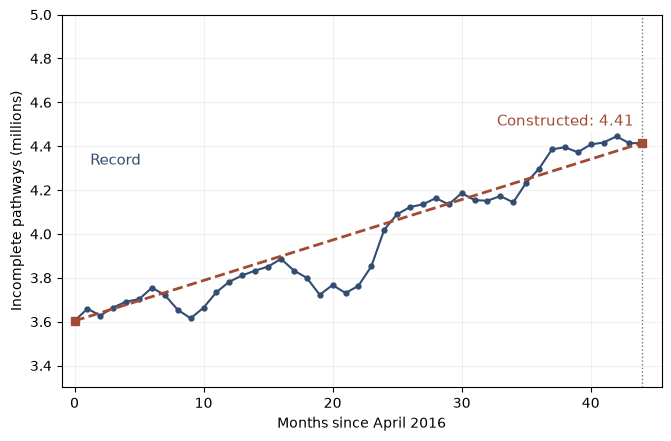

- **Gap per month in the record:** 18,439 pathways
- **Gap used in this state:** 18,439 pathways (x 1.0)
- **Months the gap is held open:** 44
- **Change in the list:** 811,305
- **List after those months (constructed):** 4,414,911
- **List in the record at that month:** 4,414,911
- **Constructed minus record:** 0
- **Referrals, first year to third (percent):** 7.5
- **Completions, first year to third (percent):** 5.6

The record's list moves from 3,603,606 to 4,414,911 in 44 months, so the average gap is (4,414,911 - 3,603,606) / 44 = 18438.75 pathways a month. This state uses 1.0 x 18438.75 = 18438.75. Held open for 44 months that is 18438.75 x 44 = 811,305, so the list reads 3,603,606 + 811,305 = 4,414,911. The record at that month reads 4,414,911. The straight line lands on the record's December 2019 count because the gap is defined by it.

In [18]:
show(gap_times_months(months=44, gap_scale=1.0))

**Use the idea.** Before arguing about referrals or activity, multiply the net gap by the months it has run.

**Where the conclusion applies.** One average gap for the whole window and no other flow. It fails when the gap changes sign inside the window, as it does in the record around 2020.

*Constructed example on the published public record: the gap is computed from the record, and the scale factor is a constructed value.*

Every setting the interactive reader offers for this demonstration:

In [19]:
sweep(gap_times_months, [('months', [24, 44]), ('gap_scale', [0.5, 1.0, 2.0])])

- **months = 24, gap_scale = 0.5**: Gap per month in the record 18,439 pathways; Gap used in this state 9,219 pathways (x 0.5); Months the gap is held open 24; Change in the list 221,265; List after those months (constructed) 3,824,871; List in the record at that month 4,019,507; Constructed minus record (-194636); Referrals, first year to third (percent) 7.5; Completions, first year to third (percent) 5.6
- **months = 24, gap_scale = 1.0**: Gap per month in the record 18,439 pathways; Gap used in this state 18,439 pathways (x 1.0); Months the gap is held open 24; Change in the list 442,530; List after those months (constructed) 4,046,136; List in the record at that month 4,019,507; Constructed minus record 26629; Referrals, first year to third (percent) 7.5; Completions, first year to third (percent) 5.6
- **months = 24, gap_scale = 2.0**: Gap per month in the record 18,439 pathways; Gap used in this state 36,878 pathways (x 2.0); Months the gap is held open 24; Change in the list 885,060; List after those months (constructed) 4,488,666; List in the record at that month 4,019,507; Constructed minus record 469159; Referrals, first year to third (percent) 7.5; Completions, first year to third (percent) 5.6
- **months = 44, gap_scale = 0.5**: Gap per month in the record 18,439 pathways; Gap used in this state 9,219 pathways (x 0.5); Months the gap is held open 44; Change in the list 405,652.5; List after those months (constructed) 4,009,258.5; List in the record at that month 4,414,911; Constructed minus record (-405652.5); Referrals, first year to third (percent) 7.5; Completions, first year to third (percent) 5.6
- **months = 44, gap_scale = 1.0**: Gap per month in the record 18,439 pathways; Gap used in this state 18,439 pathways (x 1.0); Months the gap is held open 44; Change in the list 811,305; List after those months (constructed) 4,414,911; List in the record at that month 4,414,911; Constructed minus record 0; Referrals, first year to third (percent) 7.5; Completions, first year to third (percent) 5.6
- **months = 44, gap_scale = 2.0**: Gap per month in the record 18,439 pathways; Gap used in this state 36,878 pathways (x 2.0); Months the gap is held open 44; Change in the list 1,622,610; List after those months (constructed) 5,226,216; List in the record at that month 4,414,911; Constructed minus record 811305; Referrals, first year to third (percent) 7.5; Completions, first year to third (percent) 5.6

## 2. A fit that passes and a holdout that fails

*Does a small error on 2016 to 2019 say anything about 2021 to 2026?*

The fit scores only the 45 fit months. The holdout months sit outside that window, so the same model can pass one and miss the other by a large factor.

    mean absolute percentage error on total incomplete

**Symbols and inputs.** The model is the chapter's three stock structure started in April 2016. The validation rate is the share of the list removed each month without a recorded treatment. System growth is the shared monthly growth of capacity and referrals.

**Predict first.** At the fitted values, will the error over the holdout months be closer to 4 percent or to 36 percent?

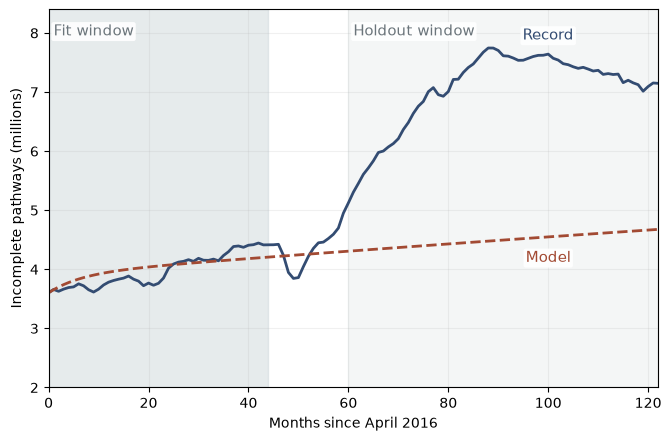

- **Validation rate (per month):** 0.06
- **System growth (per month):** 0.004
- **Fit window error (percent):** 3.63
- **Against the 5 percent tolerance:** inside
- **Holdout error (percent):** 35.57
- **Model, December 2019:** 4,206,670
- **Model, June 2026:** 4,676,007

Error at one month is |model - record| / record. December 2019: |4,206,670 - 4,414,911| / 4,414,911 = 4.7 percent. June 2026: |4,676,007 - 7,147,562| / 7,147,562 = 34.6 percent. The mean of that ratio over the 45 fit months is 3.63 percent, inside the 5 percent tolerance set before the search, and over the holdout months it is 35.57 percent. These values are read off a grid of constructed settings around the fitted ones, not refitted.

In [20]:
show(fit_and_holdout(validation_rate=0.06, system_growth=0.004))

**Use the idea.** Report the holdout error beside the fit error every time, even when it fails.

**Where the conclusion applies.** The tail steepness is held at its fitted value of 4.5, the top of its searched range. The comparison fails if definitions in the record change between windows.

*Constructed example on the published public record: the fitted values are inferred from it, and the neighbouring settings are constructed.*

Every setting the interactive reader offers for this demonstration:

In [21]:
sweep(fit_and_holdout, [('validation_rate', [0.04, 0.06, 0.08]), ('system_growth', [0.0, 0.004])])

- **validation_rate = 0.04, system_growth = 0.0**: Validation rate (per month) 0.04; System growth (per month) 0.000; Fit window error (percent) 11.48; Against the 5 percent tolerance outside; Holdout error (percent) 33.53; Model, December 2019 4,618,659; Model, June 2026 4,628,373
- **validation_rate = 0.04, system_growth = 0.004**: Validation rate (per month) 0.04; System growth (per month) 0.004; Fit window error (percent) 13.50; Against the 5 percent tolerance outside; Holdout error (percent) 27.67; Model, December 2019 4,800,656; Model, June 2026 5,194,136
- **validation_rate = 0.06, system_growth = 0.0**: Validation rate (per month) 0.06; System growth (per month) 0.000; Fit window error (percent) 4.87; Against the 5 percent tolerance inside; Holdout error (percent) 42.98; Model, December 2019 3,969,086; Model, June 2026 3,969,669
- **validation_rate = 0.06, system_growth = 0.004**: Validation rate (per month) 0.06; System growth (per month) 0.004; Fit window error (percent) 3.63; Against the 5 percent tolerance inside; Holdout error (percent) 35.57; Model, December 2019 4,206,670; Model, June 2026 4,676,007
- **validation_rate = 0.08, system_growth = 0.0**: Validation rate (per month) 0.08; System growth (per month) 0.000; Fit window error (percent) 13.12; Against the 5 percent tolerance outside; Holdout error (percent) 51.57; Model, December 2019 3,378,143; Model, June 2026 3,371,657
- **validation_rate = 0.08, system_growth = 0.004**: Validation rate (per month) 0.08; System growth (per month) 0.004; Fit window error (percent) 9.08; Against the 5 percent tolerance outside; Holdout error (percent) 41.88; Model, December 2019 3,747,279; Model, June 2026 4,253,158

## 3. Which parameter decides the long-wait stock

*Which assumed or fitted parameter moves the over 52 week stock most, and does that depend on where the rest are held?*

The swing is the gap between two runs that differ in one parameter. How big it is depends on how much of the stock the run still holds, which depends on the other settings.

    # long_share 126362

**Symbols and inputs.** Long waiters are pathways over 52 weeks, counted in the stock of that name. Each parameter is swung across a range somebody would defend, with the others held at the stated place, and read at month 20.

**Predict first.** With the others at their midpoints, which of long_share and tail_steepness moves the stock more?

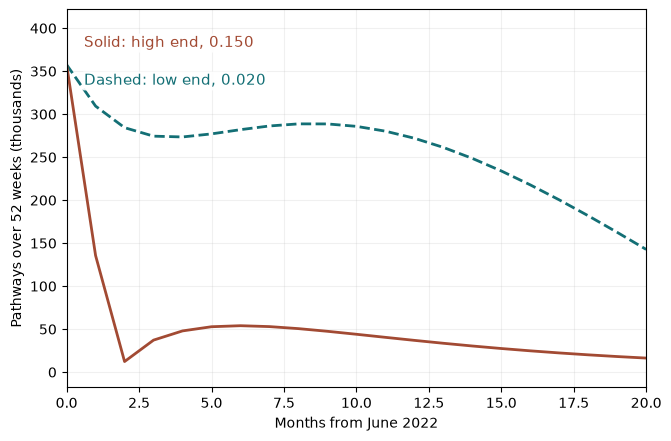

- **Parameter swung:** long_share
- **Range swung:** 0.020 to 0.150
- **Others held at:** midpoints of their ranges
- **Long waiters at month 20, low end:** 142,700
- **Long waiters at month 20, high end:** 16,339
- **Swing (pathways):** 126,362

Swing = |high end - low end| = |16,338.7 - 142,700.4| = 126,361.7, about 126,362 pathways at month 20. This is a one-at-a-time swing with the others held where stated, so it ranks parameters for this setting only. It is a chosen range, not a confidence interval.

In [22]:
show(tail_swing(parameter='long_share', hold='midpoint'))

**Use the idea.** Treat a ranking as a statement about where to measure first, under stated settings.

**Where the conclusion applies.** One parameter moves at a time and the ranges are chosen, not estimated. The ranking changes with the hold setting, so it does not rank the parameters in general.

*Constructed example on the published public record: ranges are the chapter's chosen ranges, and the fitted-values hold is a constructed variant of the midpoint hold.*

Every setting the interactive reader offers for this demonstration:

In [23]:
sweep(tail_swing, [('parameter', ['long_share', 'tail_steepness', 'complexity_penalty', 'suppression_strength']), ('hold', ['midpoint', 'fitted'])])

- **parameter = long_share, hold = midpoint**: Parameter swung long_share; Range swung 0.020 to 0.150; Others held at midpoints of their ranges; Long waiters at month 20, low end 142,700; Long waiters at month 20, high end 16,339; Swing (pathways) 126,362
- **parameter = long_share, hold = fitted**: Parameter swung long_share; Range swung 0.020 to 0.150; Others held at the fitted or assumed values; Long waiters at month 20, low end 49,568; Long waiters at month 20, high end 8,242; Swing (pathways) 41,326
- **parameter = tail_steepness, hold = midpoint**: Parameter swung tail_steepness; Range swung 0.500 to 4.500; Others held at midpoints of their ranges; Long waiters at month 20, low end 52,160; Long waiters at month 20, high end 8,164; Swing (pathways) 43,996
- **parameter = tail_steepness, hold = fitted**: Parameter swung tail_steepness; Range swung 0.500 to 4.500; Others held at the fitted or assumed values; Long waiters at month 20, low end 52,626; Long waiters at month 20, high end 8,113; Swing (pathways) 44,513
- **parameter = complexity_penalty, hold = midpoint**: Parameter swung complexity_penalty; Range swung 0.000 to 1.000; Others held at midpoints of their ranges; Long waiters at month 20, low end 13,936; Long waiters at month 20, high end 20,188; Swing (pathways) 6,252
- **parameter = complexity_penalty, hold = fitted**: Parameter swung complexity_penalty; Range swung 0.000 to 1.000; Others held at the fitted or assumed values; Long waiters at month 20, low end 5,407; Long waiters at month 20, high end 17,587; Swing (pathways) 12,180
- **parameter = suppression_strength, hold = midpoint**: Parameter swung suppression_strength; Range swung 0.000 to 0.500; Others held at midpoints of their ranges; Long waiters at month 20, low end 16,479; Long waiters at month 20, high end 16,479; Swing (pathways) 0
- **parameter = suppression_strength, hold = fitted**: Parameter swung suppression_strength; Range swung 0.000 to 0.500; Others held at the fitted or assumed values; Long waiters at month 20, low end 8,113; Long waiters at month 20, high end 8,113; Swing (pathways) 0

## 4. A recovery date, or the honest None

*When does the modelled list first reach a threshold, and when does it never?*

The function scans the run from the start and returns the first month at or under the threshold. If no month qualifies it returns None rather than a date.

    c.recovery_date(result, 6.0e6)

**Symbols and inputs.** The list is total incomplete pathways. A threshold is a count. recovery_date returns the first month the list is at or under the threshold, counted from June 2022, or None.

**Predict first.** Under the unchanged model, does the list reach 4 million within 48 months?

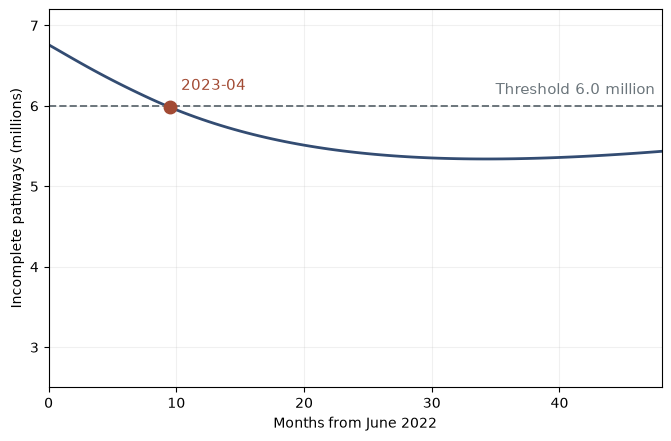

- **Policy:** baseline
- **Threshold:** 6,000,000
- **First month at or under it:** 2023-04
- **List at month 0:** 6,760,060
- **Lowest list in 48 months:** 5,340,226

The first step at or under the threshold is model month 9.5: 5,983,210 - 6,000,000 = (-16790), while the step before reads 6,016,644 - 6,000,000 = 16644. Adding 10 months to June 2022 gives 2023-04. This is a property of the fitted structure, which failed its holdout, so it is not a forecast.

In [24]:
show(recovery(policy='baseline', threshold=6000000.0))

**Use the idea.** Ask for the None branch whenever a tool hands out a date.

**Where the conclusion applies.** The fitted structure, reset to June 2022, which failed its holdout. A date here is a property of that structure and is not a forecast of the record.

*Constructed example on the published public record: policies and thresholds are the chapter's constructed values, run on the fitted structure.*

Every setting the interactive reader offers for this demonstration:

In [25]:
sweep(recovery, [('policy', ['baseline', 'uniform_uplift', 'longest_first', 'validation_push']), ('threshold', [6000000.0, 4000000.0])])

- **policy = baseline, threshold = 6000000.0**: Policy baseline; Threshold 6,000,000; First month at or under it 2023-04; List at month 0 6,760,060; Lowest list in 48 months 5,340,226
- **policy = baseline, threshold = 4000000.0**: Policy baseline; Threshold 4,000,000; First month at or under it undefined (the list stays above it for all 48 months); List at month 0 6,760,060; Lowest list in 48 months 5,340,226
- **policy = uniform_uplift, threshold = 6000000.0**: Policy uniform_uplift; Threshold 6,000,000; First month at or under it 2022-10; List at month 0 6,760,060; Lowest list in 48 months 2,943,347
- **policy = uniform_uplift, threshold = 4000000.0**: Policy uniform_uplift; Threshold 4,000,000; First month at or under it 2023-12; List at month 0 6,760,060; Lowest list in 48 months 2,943,347
- **policy = longest_first, threshold = 6000000.0**: Policy longest_first; Threshold 6,000,000; First month at or under it 2023-02; List at month 0 6,760,060; Lowest list in 48 months 5,329,107
- **policy = longest_first, threshold = 4000000.0**: Policy longest_first; Threshold 4,000,000; First month at or under it undefined (the list stays above it for all 48 months); List at month 0 6,760,060; Lowest list in 48 months 5,329,107
- **policy = validation_push, threshold = 6000000.0**: Policy validation_push; Threshold 6,000,000; First month at or under it 2022-09; List at month 0 6,760,060; Lowest list in 48 months 3,578,614
- **policy = validation_push, threshold = 4000000.0**: Policy validation_push; Threshold 4,000,000; First month at or under it 2023-12; List at month 0 6,760,060; Lowest list in 48 months 3,578,614

## Exercises

Try each before opening the answer. The settings above let you check the numbers.

### Exercise 1

If the gap were half the record's, what would the list read after 44 months?

<details><summary>Answer</summary>

Half of 18,438.75 is 9,219.375, times 44 is 405,652.5, so the list reads 3,603,606 + 405,653 = 4,009,259 (rounded).

</details>

### Exercise 2

If the model reads 5,000,000 where the record reads 4,000,000, what is that month's error?

<details><summary>Answer</summary>

|5,000,000 - 4,000,000| / 4,000,000 = 0.25, which is 25 percent.

</details>

### Exercise 3

If the high end reads 130,000 and the low end 4,000, what is the swing?

<details><summary>Answer</summary>

|130,000 - 4,000| = 126,000 pathways.

</details>

---

From *Systems Thinking with AI* by Jason Karpeles. Copyright Jason Karpeles. All rights reserved.

Interactive companion: https://karpeles.com/companions/systems-thinking-with-ai/